In [1]:
#################### Numerical & Physical Mixing in Ideal ROMS-Budgell Beaufort Jet ########################
# The purpose of this script is to plot time series of volume-averaged numerical and physical 
# mixing for salinity and temperature. Other processing for time series might be added in here, too,
# but all post-processed data will be save to netCDFs so the analysis does not need to be redone 
# to replot things. 
#
# Notes:
# - This script runs in xroms 
# - This script heavily uses code from Dylan Schlichting 
# - Other things that will maybe be added into here: energy analysis of eddy things, 
#   M2 and N2, ice volume/concentration/whatever is standard in papers
# - Choose an area that always has eddies, vertical slices constrained to top 200 m, 
# - I think I am going to add things for ice variables into here...

##############################################################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import matplotlib.gridspec as gridspec
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions 
Make functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

## Post-Processing  
Load in and process the model output.

In [6]:
# Constant forcing (time series), ice, U3C4, K-eps
path_const_u3c4_keps = glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_gen = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_kkl = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_komega = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc')
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_kpp = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')

In [7]:
# Load in the output from above with xroms
ds, grid = open_mfroms(path_const_u3c4_keps)
add_derivatives(ds, grid)

<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Thursday - January 1, 2026 -  7:17:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [8]:
print(ds.ocean_time[0:5].values)
print(ds.ocean_time[-5:-1].values)

[cftime.DatetimeProlepticGregorian(1, 1, 1, 1, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 3, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 5, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 7, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 9, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeProlepticGregorian(1, 4, 30, 15, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 17, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 19, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 21, 0, 0, 0, has_year_zero=True)]


## Mixing!  
Calculate mixing in the domain. First pick the region we want to do calculations over.

In [9]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [10]:
print(len(ds.y_rho[:,0]))
print(len(y_rho))

1002
1002


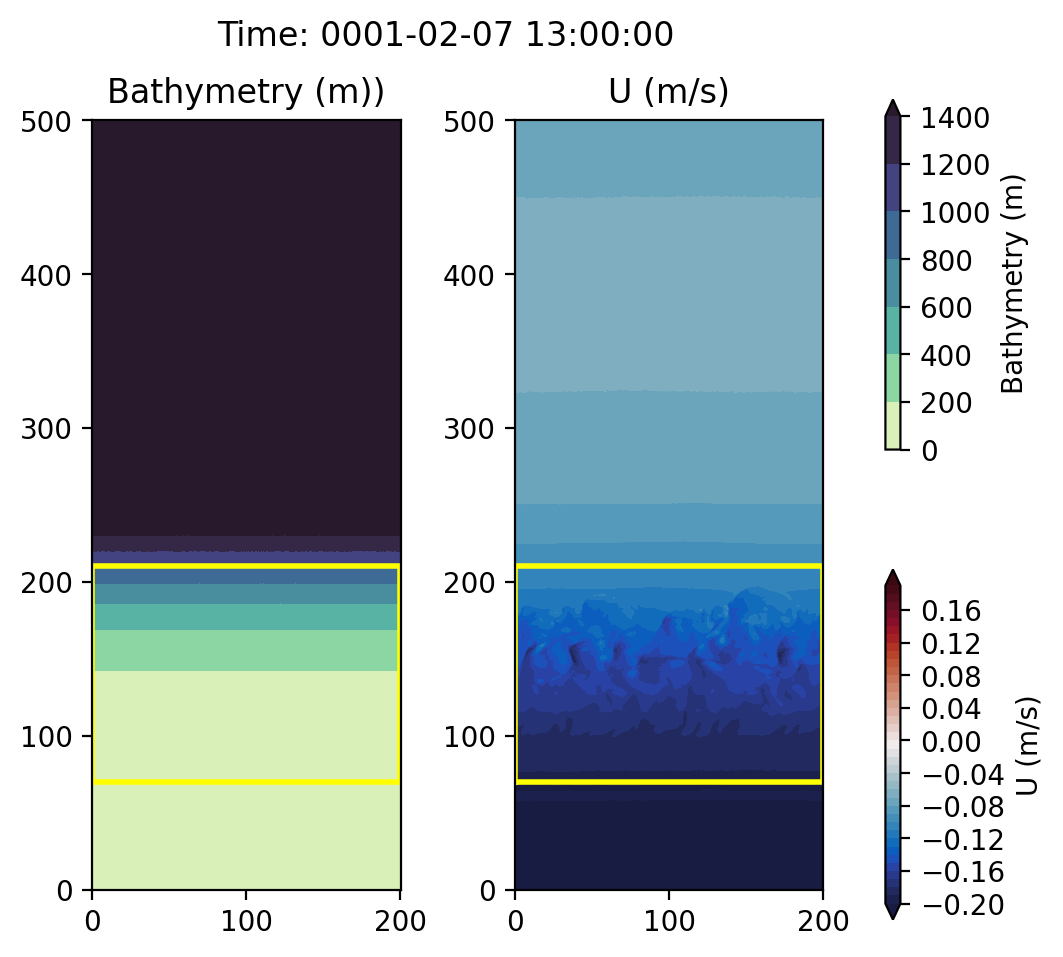

In [11]:
# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds.h, cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()
 

In [12]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0


In [13]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

### Physical & Numerical Mixing  
Calculate mixing in that box and in top 200 m of the water column

In [14]:
ds.ocean_time[0:5].values

array([cftime.DatetimeProlepticGregorian(1, 1, 1, 1, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1, 1, 1, 3, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1, 1, 1, 5, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1, 1, 1, 7, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1, 1, 1, 9, 0, 0, 0, has_year_zero=True)],
      dtype=object)

In [15]:
ds.z_rho[0,:,100,100].values

array([-16.79985239, -16.19436146, -15.60789784, -15.03994807,
       -14.48976024, -13.95641529, -13.43888648, -12.93608764,
       -12.44691127, -11.97025778, -11.50505714, -11.05028436,
       -10.60496987, -10.16820586,  -9.73914957,  -9.31702419,
        -8.90111796,  -8.49078213,  -8.085428  ,  -7.68452342,
        -7.28758905,  -6.8941944 ,  -6.50395399,  -6.11652353,
        -5.73159628,  -5.34889967,  -4.9681921 ,  -4.58926001,
        -4.21191523,  -3.83599254,  -3.46134751,  -3.08785452,
        -2.7154051 ,  -2.3439064 ,  -1.97327987,  -1.60346018,
        -1.23439426,  -0.86604056,  -0.49836843,  -0.13135768])

In [ ]:
# Get physical mixing from the output
# Salinity (2-hourly)
Akr_rho = grid.interp(ds.AKr, 'Z')
mphys = (Akr_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphys.attrs = ''

# Temperature (2-hourly)
Akrt_rho = grid.interp(ds.AKrt, 'Z')
mphyt = (Akrt_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphyt.attrs = ''

In [ ]:
# Get numerical mixing from the output
# Numerical mixing (2-hourly)
mnum_salt_dv = (ds.dye_03*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mnum_temp_dv = (ds.dye_06*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()

### Save to NetCDF  
Save the post-processed data to a netCDF

In [ ]:
# Save all the 2-hourly data to the same netcdf

# Variables to save: mphys, mphyt, mnum_salt_dv, mnum_temp_dv

roms_phy_num_mix_salt_temp = xr.Dataset(
    data_vars=dict(
        mphys=(['ocean_time'], mphys.values),
        mphyt=(['ocean_time'], mphyt.values),
        mnum_salt_dv=(['ocean_time'], mnum_salt_dv.values),
        mnum_temp_dv=(['ocean_time'], mnum_temp_dv.values)
    ),
    coords=dict(
        ocean_time=('ocean_time', ds.ocean_time.values)
    ),
    attrs=dict(description='Time-series ROMS output including physical and numerical mixing of salinity and temperature from 2-hourly model output; uses /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
)

# Add attributes to the 'temperature' data variable
roms_phy_num_mix_salt_temp['mphys'].attrs['long_name'] = 'Physical mixing of salinity at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphys'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mphyt'].attrs['long_name'] = 'Physical mixing of temperature at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphyt'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['long_name'] = 'Numerical mixing of salinity at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['long_name'] = 'Numerical mixing of temperature at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

# Save to a netcdf
# Run with ice (change name based on the run being analyzed)
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_gen_001.nc')
# Run without ice
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')


## Plot Mixing  
Plot timeseries of the mixing to compare 

In [16]:
# If post-processed data is ready, load it in
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
roms_phy_num_mix_u3c4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_keps_001.nc')

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
roms_phy_num_mix_u3c4_keps_no_ice = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_phy_num_mix_salt_temp_2hr_500m_const_forc_no_ice_u3c4_keps_001.nc')

# Constant forcing, U3C4, gen
roms_phy_num_mix_u3c4_gen = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_gen_002.nc')

# Constant forcing, U3C4, kkl
roms_phy_num_mix_u3c4_kkl = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_kkl_001.nc')

# Constant forcing, U3C4, k-omega
roms_phy_num_mix_u3c4_komega = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_komega_001.nc')

# Constant forcing, U3C4, kpp
roms_phy_num_mix_u3c4_kpp = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_phy_num_mix_salt_temp_2hr_500m_const_forc_u3c4_kpp_002.nc')

# Constant forcing, akima, k-epsilon
roms_phy_num_mix_akima_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_akima_keps_001.nc')

# Constant forcing, HSIMT, k-epsilon
roms_phy_num_mix_hsimt_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_hsimt_keps_001.nc')

# Constant forcing, MPDATA, k-epsilon
roms_phy_num_mix_mpdata_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_mpdata_keps_001.nc')

# Constant forcing, u3splitc4, k-epsilon
roms_phy_num_mix_u3splitc4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3splitc4_keps_001.nc')



In [17]:
# Make a time for each output
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
time_tmp = roms_phy_num_mix_u3c4_keps['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
time_tmp = roms_phy_num_mix_u3c4_keps_no_ice['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_keps_no_ice = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, gen
time_tmp = roms_phy_num_mix_u3c4_gen['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_gen = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kkl
time_tmp = roms_phy_num_mix_u3c4_kkl['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_kkl = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, k-omega
time_tmp = roms_phy_num_mix_u3c4_komega['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_komega = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kpp
time_tmp = roms_phy_num_mix_u3c4_kpp['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_kpp = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, akima, k-epsilon
time_tmp = roms_phy_num_mix_akima_keps['ocean_time']
t0 = time_tmp.values[0]
time_akima_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, HSIMT, k-epsilon
time_tmp = roms_phy_num_mix_hsimt_keps['ocean_time']
t0 = time_tmp.values[0]
time_hsimt_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, MPDATA, k-epsilon
time_tmp = roms_phy_num_mix_mpdata_keps['ocean_time']
t0 = time_tmp.values[0]
time_mpdata_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, u3splitc4, k-epsilon
time_tmp = roms_phy_num_mix_u3splitc4_keps['ocean_time']
t0 = time_tmp.values[0]
time_u3splitc4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Make time array to use for plotting 
# # Time vector
# # I think do some stuff to get a vector of time for plotting?
# time = ds['ocean_time']
# t0 = time.values[0]

# time = np.array([
#     (t - t0).total_seconds() / 86400
#     for t in time.values
# ])

In [18]:
# Re-assign the data from the post-processed data to work 
# with the plots below 
# Run with ice
# mphys_ice = roms_phy_num_mix_u3c4_keps.mphys
# mphyt_ice = roms_phy_num_mix_u3c4_keps.mphyt
# mnum_salt_dv_ice = roms_phy_num_mix_u3c4_keps.mnum_salt_dv
# mnum_temp_dv_ice = roms_phy_num_mix_u3c4_keps.mnum_temp_dv


# # Run without ice 
# mphys_no_ice = roms_phy_num_mix_no_ice.mphys
# mphyt_no_ice = roms_phy_num_mix_no_ice.mphyt
# mnum_salt_dv_no_ice = roms_phy_num_mix_no_ice.mnum_salt_dv
# mnum_temp_dv_no_ice = roms_phy_num_mix_no_ice.mnum_temp_dv


NameError: name 'time' is not defined

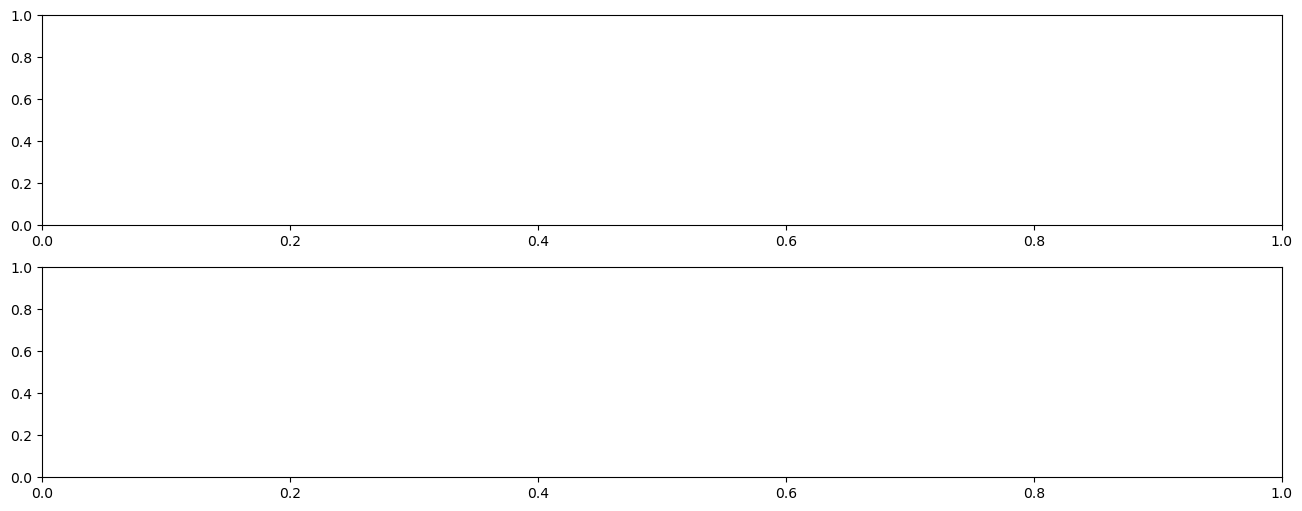

In [17]:
# Plot these comparisons 
# Compare phsyical and numerical mixing of salinity and temperature for the
# 2-hourly run
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
ax[0].plot(time, mphys_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time, mnum_salt_dv_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt}$')
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
ax[1].plot(time, mphyt_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time, mnum_temp_dv_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp}$')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_500m_const_forc_u3c4_keps_001.png')

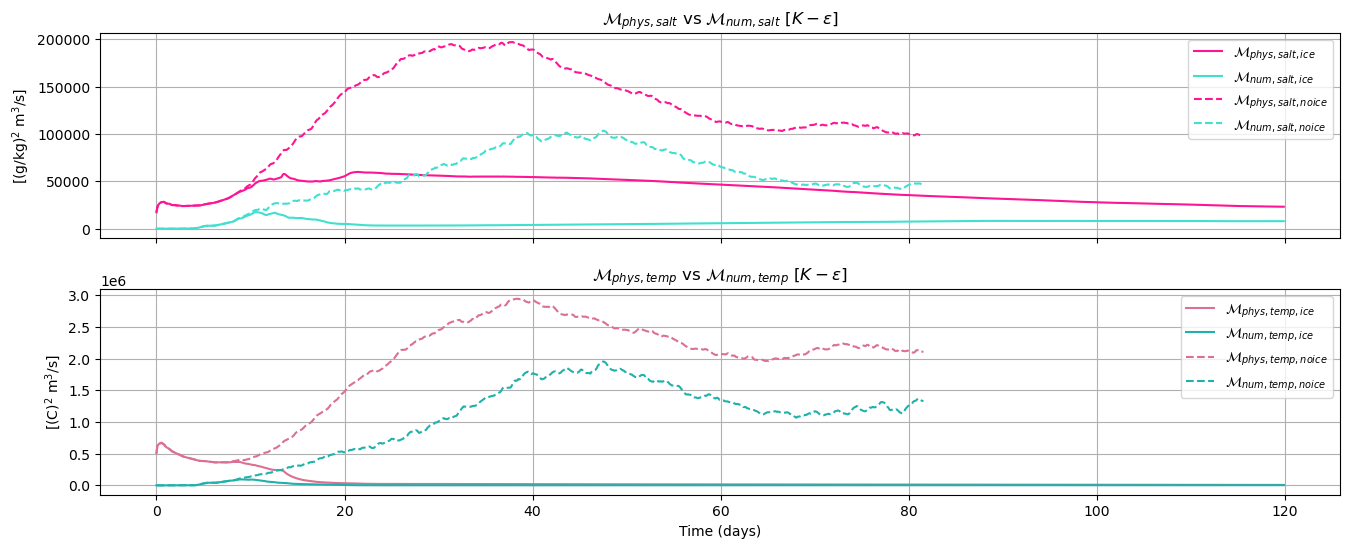

In [19]:
# Make a plot comparing run with ice to run witout ice
# Be sure to only compare the overlapping times 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,salt,ice}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,salt,ice}$')
# No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$ [$K-\epsilon$]')

# Plot physical and numerical mixing of temperature 
# Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,ice}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,ice}$')
# No ice
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$ [$K-\epsilon$]')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

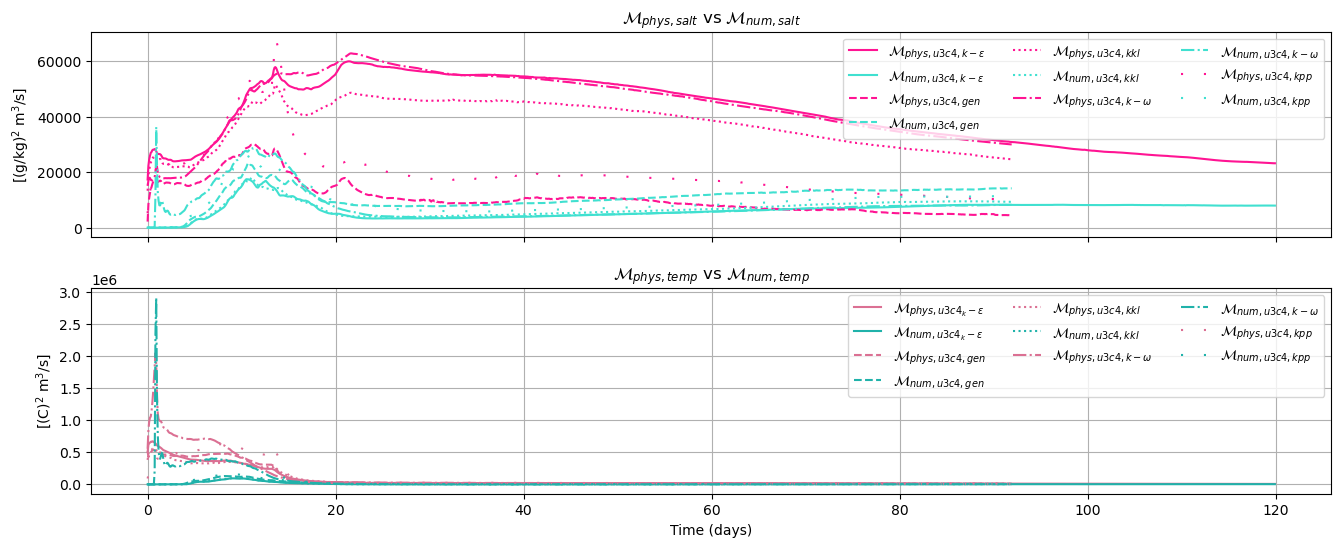

In [20]:
# Make a plot comparing the different vertical mixing schemes 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[0].plot(time, mphys_no_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
# #ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
# ax[0].plot(time, mnum_salt_dv_no_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,gen}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,kkl}$', linestyle=':')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle=':')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$', linestyle='-.')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='-.')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,kpp}$', linestyle=(0, (1, 10)))
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle=(0, (1, 10)))


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4_k-\epsilon}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4_k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[1].plot(time, mphyt_no_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
# ax[1].plot(time, mnum_temp_dv_no_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,gen}$', linestyle='--')
ax[1].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,kkl}$', linestyle=':')
ax[1].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle=':')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$', linestyle='-.')
ax[1].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='-.')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,kpp}$', linestyle=(0, (1, 10)))
ax[1].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle=(0, (1, 10)))


# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend(ncols=3)
ax[0].set_xticklabels('')
ax[1].legend(ncols=3)
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

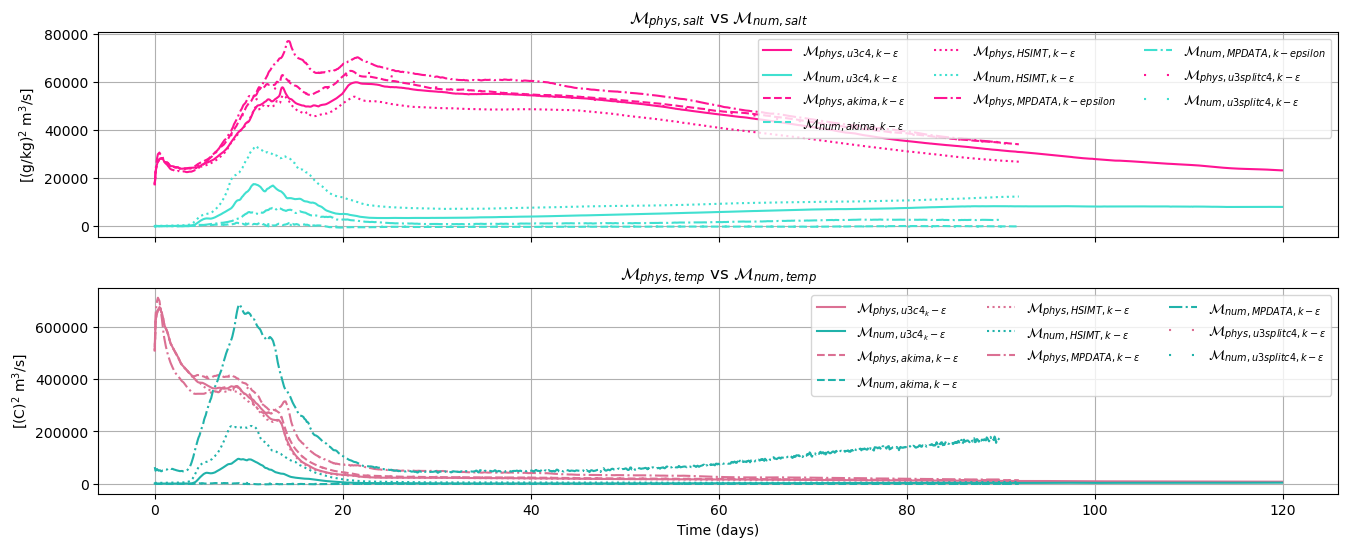

In [21]:
# Do this again but for horizontal advection schemes 
# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[0].plot(time, mphys_no_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
# #ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
# ax[0].plot(time, mnum_salt_dv_no_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# akima k-epsilon
ax[0].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[0].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$', linestyle=':')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
ax[0].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$', linestyle='-.')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='-.')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4_k-\epsilon}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4_k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[1].plot(time, mphyt_no_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
# ax[1].plot(time, mnum_temp_dv_no_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# akima k-epsilon
ax[1].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$', linestyle='--')
ax[1].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[1].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$', linestyle=':')
ax[1].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
ax[1].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,MPDATA,k-\epsilon}$', linestyle='-.')
ax[1].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,MPDATA,k-\epsilon}$', linestyle='-.')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))
ax[1].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))


# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend(ncols=3)
ax[0].set_xticklabels('')
ax[1].legend(ncols=3)
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

In [22]:
# Make colors to use
#mixing_colors_all = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#7f7f7f']
#mixing_colors_all = ['#f0e442', '#e69f00', '#56b4e9', '#009e73', '#0072b2', '#d55e00', '#e377c2', '#4eab58', '#db6d00', '#d628c1']
mixing_colors_all = ["#fec64e", 'dimgrey', '#56b4e9', '#009e73', '#0072b2', '#d55e00', '#e377c2', '#4eab58', '#db6d00', '#d628c1']

In [23]:
len(time_u3c4_keps_no_ice)

980

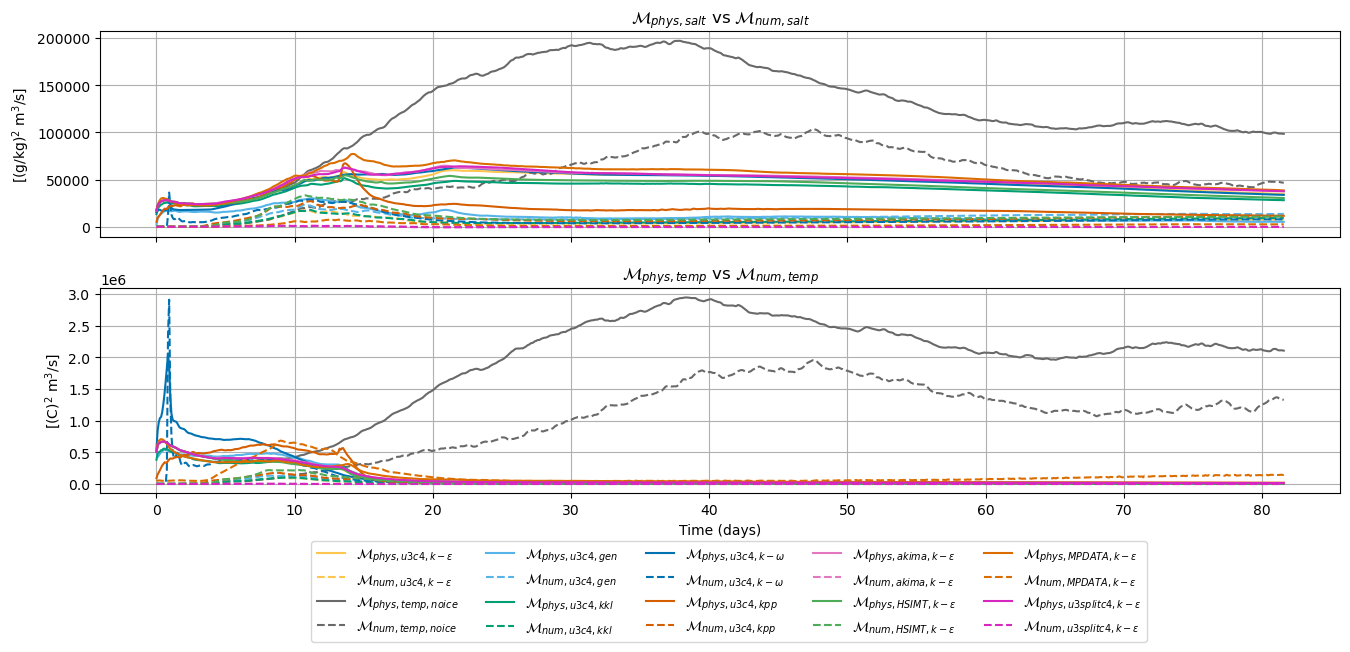

In [24]:
# Make giant plot comparing all of them

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-\epsilon}$')
ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-\epsilon}$', linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')



# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].legend(ncols=5, bbox_to_anchor=(0.85, -0.2))
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

In [25]:
# OR can combine the above ones as different panelsssss

In [26]:
# Prep the sea ice data for all the runs 


## Sea Ice Stuff  
Do some processing of ice things and plot them here, too

In [27]:
# Load in runs for sea ice analysis 

# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps_no_ice = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_no_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, U3C4, gen
ds_ice_u3c4_gen = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
ds_ice_u3c4_kkl = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
ds_ice_u3c4_komega = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc')
# Constant forcing, U3C4, kpp
ds_ice_u3c4_kpp = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')
# Constant forcing, akima, k-epsilon
ds_ice_akima_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_akima_keps_*.nc')
# Constant forcing, HSIMT, k-epsilon
ds_ice_hsimt_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_HSIMT_keps_*.nc')
# Constant forcing, MPDATA, k-epsilon
ds_ice_mpdata_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_mpdata_keps_*.nc')
# Constant forcing, u3splitc4, k-epsilon
ds_ice_u3splitc4_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3splitc4_keps_*.nc')


In [28]:
# Make time for each run
time_u3c4_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_keps.ocean_time.values])
time_u3c4_keps_no_ice = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_keps_no_ice.ocean_time.values])
time_u3c4_gen = np.array([(t - ds_ice_u3c4_gen.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_gen.ocean_time.values])
time_u3c4_kkl = np.array([(t - ds_ice_u3c4_kkl.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_kkl.ocean_time.values])
time_u3c4_komega = np.array([(t - ds_ice_u3c4_komega.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_komega.ocean_time.values])
time_u3c4_kpp = np.array([(t - ds_ice_u3c4_kpp.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_kpp.ocean_time.values])
time_akima_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_akima_keps.ocean_time.values])
time_hsimt_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_hsimt_keps.ocean_time.values])
time_mpdata_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_mpdata_keps.ocean_time.values])
time_u3splitc4_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3splitc4_keps.ocean_time.values])

In [29]:
# Assign a color to each run
#run_colors = ['blue', 'mediumspringgreen', 'lightseagreen', 'darkviolet', 'mediumpurple']
run_colors = ['blue', 'mediumspringgreen', 'orange', 'darkviolet', 'red']
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

#### Post-Process Ice Data  
If needed, post-process all of the ice data to get time series of vulme and average concentration in the box for all runs.

In [26]:
# Apparently (varinfo.yaml) ice_thickness is the average 
# ice thickness in a cell so assuming that is true, multiply
# by cell area to get volume
# Assuming the grid is same resolution everywhere, get area
cell_area = dx * dy

# Now get volume
ice_vol_u3c4_keps = ds_ice_u3c4_keps.ice_thickness*cell_area
ice_vol_u3c4_gen = ds_ice_u3c4_gen.ice_thickness*cell_area
ice_vol_u3c4_kkl = ds_ice_u3c4_kkl.ice_thickness*cell_area
ice_vol_u3c4_komega = ds_ice_u3c4_komega.ice_thickness*cell_area
ice_vol_u3c4_kpp = ds_ice_u3c4_kpp.ice_thickness*cell_area
ice_vol_akima_keps = ds_ice_akima_keps.ice_thickness*cell_area
ice_vol_hsimt_keps = ds_ice_hsimt_keps.ice_thickness*cell_area
ice_vol_mpdata_keps = ds_ice_mpdata_keps.ice_thickness*cell_area
ice_vol_u3splitc4_keps = ds_ice_u3splitc4_keps.ice_thickness*cell_area

In [ ]:
# Take the total over the region of interest indicated above
# Trim to this region
ice_vol_u3c4_keps_reg1 = ice_vol_u3c4_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_gen_reg1 = ice_vol_u3c4_gen.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_kkl_reg1 = ice_vol_u3c4_kkl.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_komega_reg1 = ice_vol_u3c4_komega.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_kpp_reg1 = ice_vol_u3c4_kpp.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_akima_keps_reg1 = ice_vol_akima_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_hsimt_keps_reg1 = ice_vol_hsimt_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_mpdata_keps_reg1 = ice_vol_mpdata_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3splitc4_keps_reg1 = ice_vol_u3splitc4_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
print(np.shape(ice_vol_u3c4_keps_reg1))

# Now sum over this region to get total ice volume 
ice_vol_u3c4_keps_reg1_tot = ice_vol_u3c4_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_gen_reg1_tot = ice_vol_u3c4_gen_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_kkl_reg1_tot = ice_vol_u3c4_kkl_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_komega_reg1_tot = ice_vol_u3c4_komega_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_kpp_reg1_tot = ice_vol_u3c4_kpp_reg1.sum(axis=(1,2)).compute()
ice_vol_akima_keps_reg1_tot = ice_vol_akima_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_hsimt_keps_reg1_tot = ice_vol_hsimt_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_mpdata_keps_reg1_tot = ice_vol_mpdata_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_u3splitc4_keps_reg1_tot = ice_vol_u3splitc4_keps_reg1.sum(axis=(1,2)).compute()

In [ ]:
# Plot time series of ice volume 
fig, ax = plt.subplots(2, figsize=(12,4))

# Plot ice volume - linear y-axis
ax[0].plot(time_u3c4_keps, ice_vol_u3c4_keps_reg1_tot, color=run_colors[0], label=r'U3C4, k-eps')
ax[0].plot(time_u3c4_gen, ice_vol_u3c4_gen_reg1_tot, color=run_colors[1], label=r'U3C4, gen')
ax[0].plot(time_u3c4_kkl, ice_vol_u3c4_kkl_reg1_tot, color=run_colors[2], label=r'U3C4, kkl')
ax[0].plot(time_u3c4_komega, ice_vol_u3c4_komega_reg1_tot, color=run_colors[3], label=r'U3C4, k-omega')
ax[0].plot(time_u3c4_kpp, ice_vol_u3c4_kpp_reg1_tot, color=run_colors[4], label=r'U3C4, kpp')

# Plot ice volume - log y-axis
ax[1].plot(time_u3c4_keps, ice_vol_u3c4_keps_reg1_tot, color=run_colors[0], label=r'U3C4, k-eps')
ax[1].plot(time_u3c4_gen, ice_vol_u3c4_gen_reg1_tot, color=run_colors[1], label=r'U3C4, gen')
ax[1].plot(time_u3c4_kkl, ice_vol_u3c4_kkl_reg1_tot, color=run_colors[2], label=r'U3C4, kkl')
ax[1].plot(time_u3c4_komega, ice_vol_u3c4_komega_reg1_tot, color=run_colors[3], label=r'U3C4, k-omega')
ax[1].plot(time_u3c4_kpp, ice_vol_u3c4_kpp_reg1_tot, color=run_colors[4], label=r'U3C4, kpp')


# Label the axes
ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel('$m^{3}$', rotation=0, va='center', labelpad=35)
ax[1].set_ylabel('$m^{3}$', rotation=0, va='center')
ax[0].set_title(r'Ice Volume')

ax[0].legend()

ax[1].semilogy()
ax[1].set_ylim(1e-1, 1e11)
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/ice_vol_reg1_ice_500m_const_forc_u3c4_keps_001.png')


In [ ]:
# Calculte average ice concentration in this region
# Get the part in this region
ice_conc_u3c4_keps_reg1 = ds_ice_u3c4_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_gen_reg1 = ds_ice_u3c4_gen.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_kkl_reg1 = ds_ice_u3c4_kkl.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_komega_reg1 = ds_ice_u3c4_komega.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_kpp_reg1 = ds_ice_u3c4_kpp.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_akima_keps_reg1 = ds_ice_akima_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_hsimt_keps_reg1 = ds_ice_hsimt_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_mpdata_keps_reg1 = ds_ice_mpdata_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3splitc4_keps_reg1 = ds_ice_u3splitc4_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)

# Take the average over space 
ice_conc_u3c4_keps_reg1_avg = ice_conc_u3c4_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_gen_reg1_avg = ice_conc_u3c4_gen_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_kkl_reg1_avg = ice_conc_u3c4_kkl_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_komega_reg1_avg = ice_conc_u3c4_komega_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_kpp_reg1_avg = ice_conc_u3c4_kpp_reg1.mean(axis=(1,2)).compute()
ice_conc_akima_keps_reg1_avg = ice_conc_akima_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_hsimt_keps_reg1_avg = ice_conc_hsimt_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_mpdata_keps_reg1_avg = ice_conc_mpdata_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_u3splitc4_keps_reg1_avg = ice_conc_u3splitc4_keps_reg1.mean(axis=(1,2)).compute()

#### Save to a NetCDF

In [ ]:
# Save ice things to netCDFs since they take a little 
# while to calculate
roms_ice_vol_conc = xr.Dataset(
    data_vars=dict(
        ice_vol_u3c4_keps_tot=(['ocean_time'], ice_vol_u3c4_keps_reg1_tot[:980].values),
        ice_vol_u3c4_gen_tot=(['ocean_time'], ice_vol_u3c4_gen_reg1_tot[:980].values),
        ice_vol_u3c4_kkl_tot=(['ocean_time'], ice_vol_u3c4_kkl_reg1_tot[:980].values),
        ice_vol_u3c4_komega_tot=(['ocean_time'], ice_vol_u3c4_komega_reg1_tot[:980].values),
        ice_vol_u3c4_kpp_tot=(['ocean_time'], ice_vol_u3c4_kpp_reg1_tot[:980].values),
        ice_vol_akima_keps_tot=(['ocean_time'], ice_vol_akima_keps_reg1_tot[:980].values),
        ice_vol_hsimt_keps_tot=(['ocean_time'], ice_vol_hsimt_keps_reg1_tot[:980].values),
        ice_vol_mpdata_keps_tot=(['ocean_time'], ice_vol_mpdata_keps_reg1_tot[:980].values),
        ice_vol_u3splitc4_keps_tot=(['ocean_time'], ice_vol_u3splitc4_keps_reg1_tot[:980].values),
        ice_conc_u3c4_keps_avg=(['ocean_time'], ice_conc_u3c4_keps_reg1_avg[:980].values),
        ice_conc_u3c4_gen_avg=(['ocean_time'], ice_conc_u3c4_gen_reg1_avg[:980].values),
        ice_conc_u3c4_kkl_avg=(['ocean_time'], ice_conc_u3c4_kkl_reg1_avg[:980].values),
        ice_conc_u3c4_komega_avg=(['ocean_time'], ice_conc_u3c4_komega_reg1_avg[:980].values),
        ice_conc_u3c4_kpp_avg=(['ocean_time'], ice_conc_u3c4_kpp_reg1_avg[:980].values),
        ice_conc_akima_keps_avg=(['ocean_time'], ice_conc_akima_keps_reg1_avg[:980].values),
        ice_conc_hsimt_keps_avg=(['ocean_time'], ice_conc_hsimt_keps_reg1_avg[:980].values),
        ice_conc_mpdata_keps_avg=(['ocean_time'], ice_conc_mpdata_keps_reg1_avg[:980].values),
        ice_conc_u3splitc4_keps_avg=(['ocean_time'], ice_conc_u3splitc4_keps_reg1_avg[:980].values),
    ),
    coords=dict(
        ocean_time=('ocean_time', time_u3c4_keps[:980])
    ),
    attrs=dict(description='Time-series of total ice volume and average ice concentration of ROMS output from 2-hourly model output for all runs; values are for boxed region used for all analyses')
)

# Add attributes to the 'temperature' data variable
# Ice volume 
roms_ice_vol_conc['ice_vol_u3c4_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, k-epsilon'
roms_ice_vol_conc['ice_vol_u3c4_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_gen_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, gen'
roms_ice_vol_conc['ice_vol_u3c4_gen_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_kkl_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, kkl'
roms_ice_vol_conc['ice_vol_u3c4_kkl_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_komega_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, k-omega'
roms_ice_vol_conc['ice_vol_u3c4_komega_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_kpp_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, kpp'
roms_ice_vol_conc['ice_vol_u3c4_kpp_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_akima_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, akima, k-epsilon'
roms_ice_vol_conc['ice_vol_akima_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_hsimt_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, HSIMT, k-epsilon'
roms_ice_vol_conc['ice_vol_hsimt_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_mpdata_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, MPDATA, k-epsilon'
roms_ice_vol_conc['ice_vol_mpdata_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3splitc4_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3splitC4, k-epsilon'
roms_ice_vol_conc['ice_vol_u3splitc4_keps_tot'].attrs['units'] = '$m^{3}$'
# Ice concentration 
roms_ice_vol_conc['ice_conc_u3c4_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, k-epsilon'
roms_ice_vol_conc['ice_conc_u3c4_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_gen_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, gen'
roms_ice_vol_conc['ice_conc_u3c4_gen_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_kkl_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, kkl'
roms_ice_vol_conc['ice_conc_u3c4_kkl_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_komega_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, k-omega'
roms_ice_vol_conc['ice_conc_u3c4_komega_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_kpp_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, kpp'
roms_ice_vol_conc['ice_conc_u3c4_kpp_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_akima_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, akima, k-epsilon'
roms_ice_vol_conc['ice_conc_akima_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_hsimt_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, HSIMT, k-epsilon'
roms_ice_vol_conc['ice_conc_hsimt_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_mpdata_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, MPDATA, k-epsilon'
roms_ice_vol_conc['ice_conc_mpdata_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3splitc4_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3splitC4, k-epsilon'
roms_ice_vol_conc['ice_conc_u3splitc4_keps_avg'].attrs['units'] = 'fraction'



# Save to a netcdf
# All runs
#roms_ice_vol_conc.to_netcdf('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_ice_vol_conc_2hr_ice_all_runs_001.nc')


### Plot Sea Ice Data  
Load in post-processed sea ice data and plot it

In [30]:
# Load in ice data to use for plotting
roms_ice_vol_conc_ds = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_ice_vol_conc_2hr_ice_all_runs_001.nc')

In [31]:
# Could make all of this ice analysis a function at some point....
# buttt that's okay for now

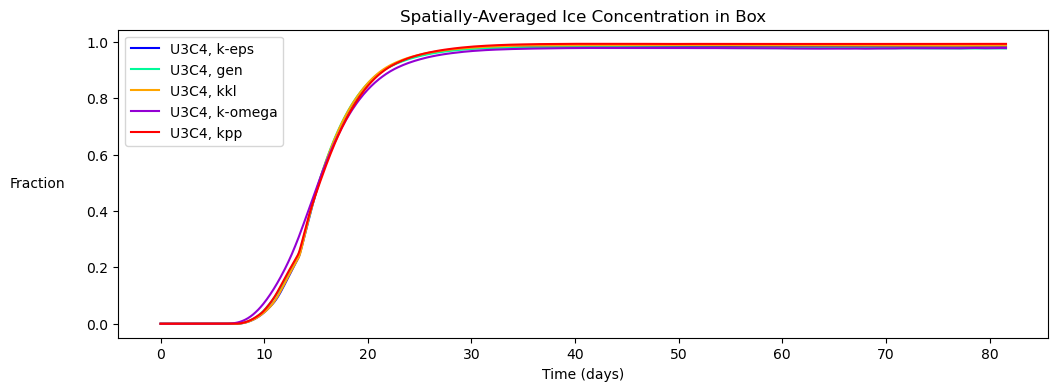

In [32]:
# Plot time series of ice volume 
fig, ax = plt.subplots(figsize=(12,4))

# Plot ice volume
ax.plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=run_colors[0], label=r'U3C4, k-eps')
ax.plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=run_colors[1], label=r'U3C4, gen')
ax.plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=run_colors[2], label=r'U3C4, kkl')
ax.plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=run_colors[3], label=r'U3C4, k-omega')
ax.plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=run_colors[4], label=r'U3C4, kpp')

# Label the axes
ax.set_xlabel('Time (days)')
ax.set_ylabel('Fraction', rotation=0, va='center', labelpad=35)
ax.set_title(r'Spatially-Averaged Ice Concentration in Box')

ax.legend()

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/avg_ice_conc_reg1_ice_500m_const_forc_u3c4_keps_001.png')

In [32]:
# Plot combined time series of mixing things and ice volume (maybe?) 


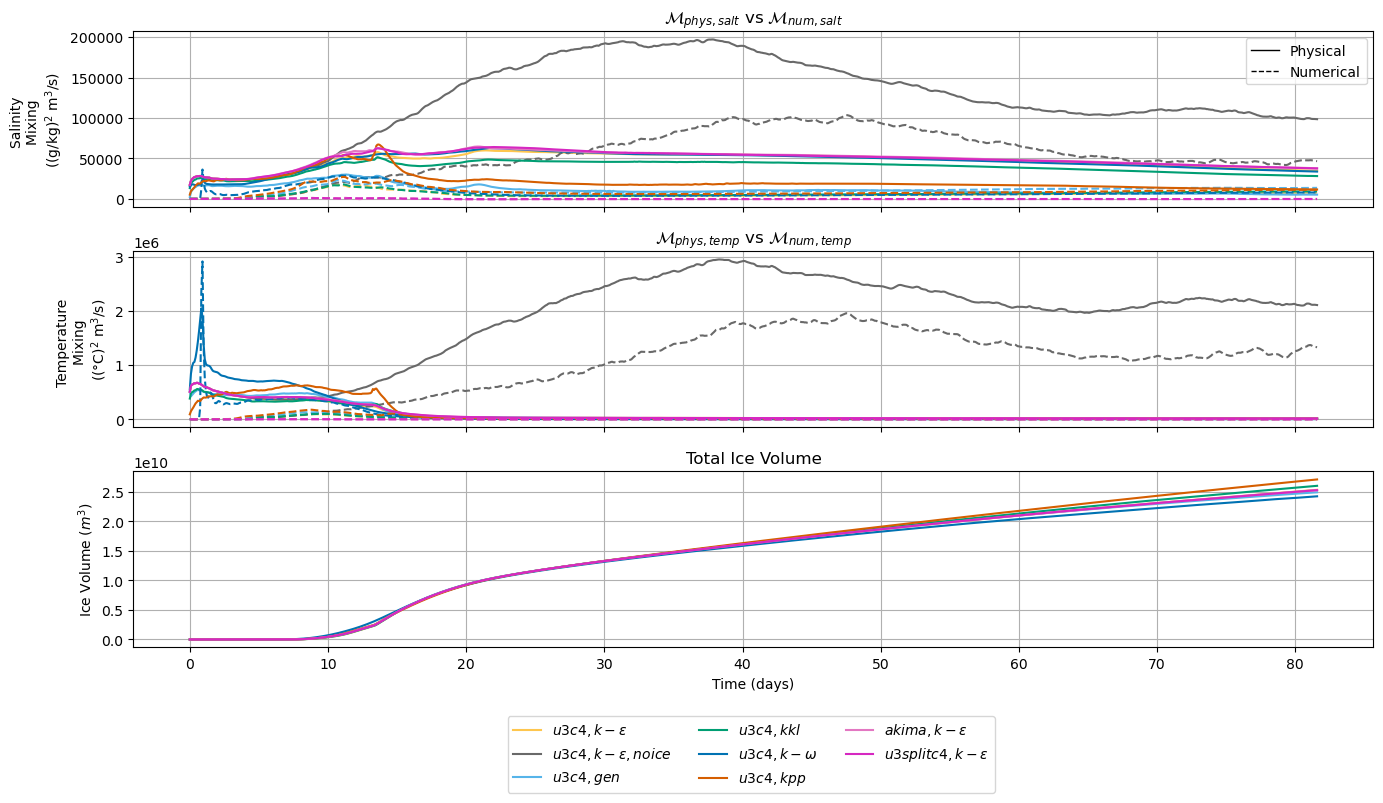

In [33]:
# Make same plot as above (maybe) but add on sea ice timing things 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(3, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Ice Volume ($m^{3}$)')
ax[2].set_title(r'Total Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -1.6))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

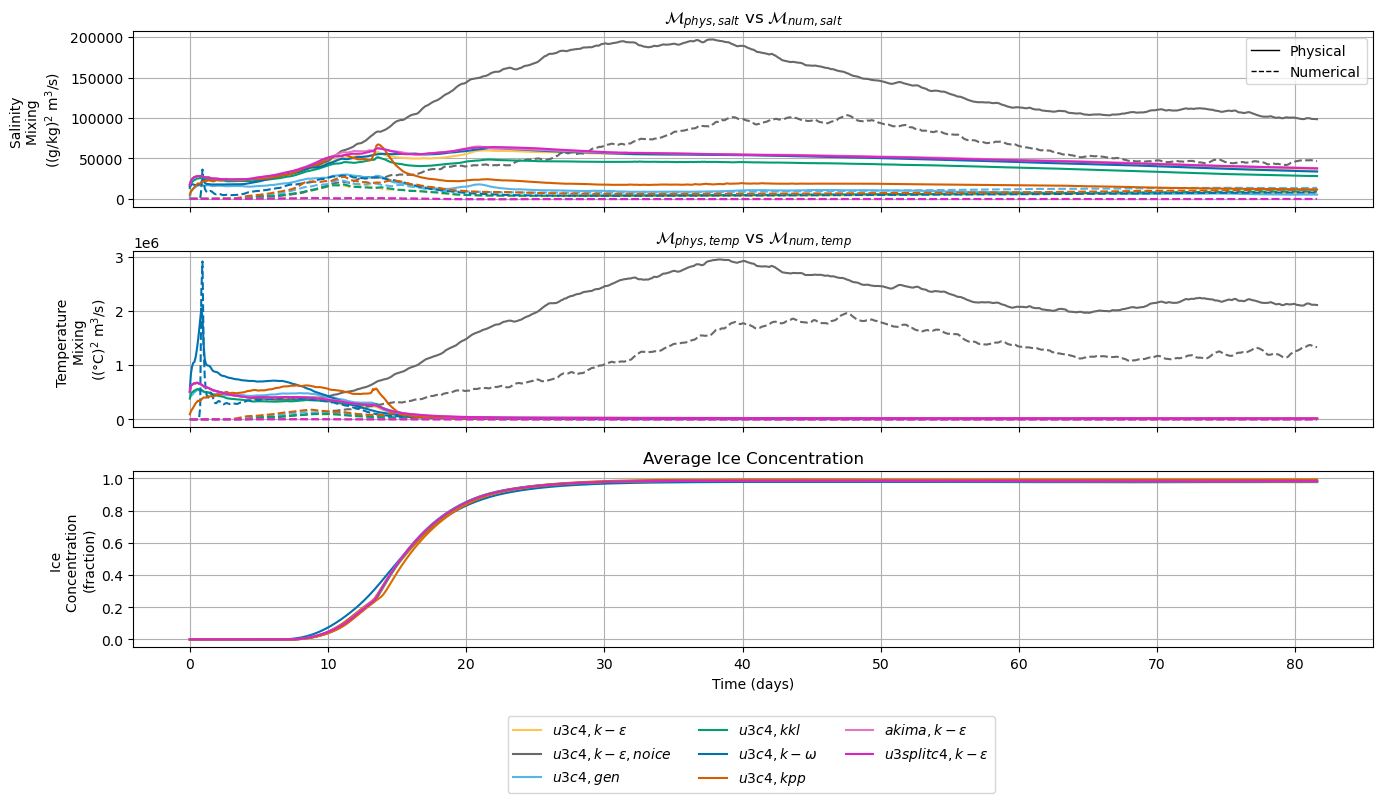

In [34]:
# Make same plot but with average ice concentration instead

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(3, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Ice \nConcentration \n(fraction)')
ax[2].set_title(r'Average Ice Concentration')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -1.6))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

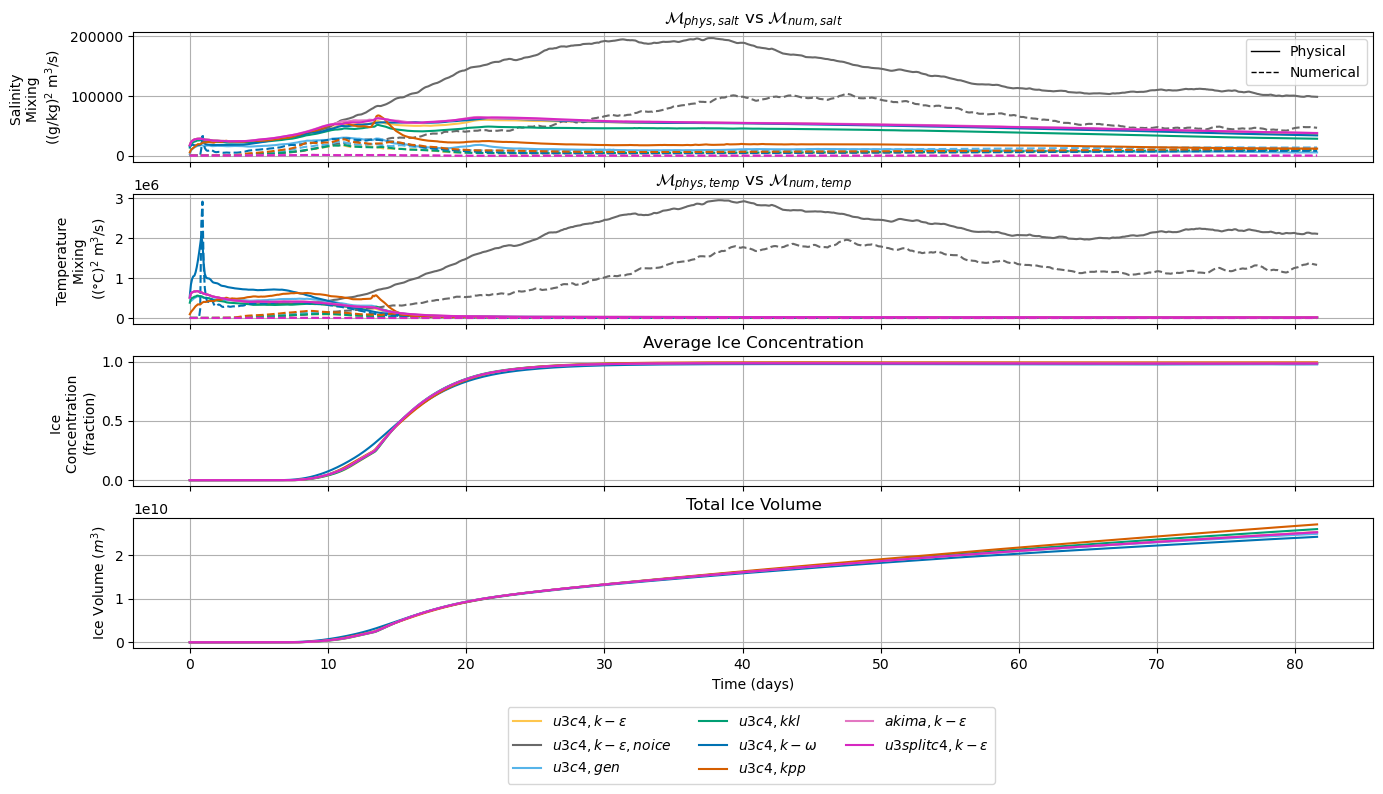

In [35]:
# Make same plot with both ice variables 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(4, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_ylabel('Ice \nConcentration \n(fraction)')
ax[2].set_title(r'Average Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[3].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[3].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[3].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[3].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[3].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[3].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[3].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[3].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[3].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[3].set_xlabel('Time (days)')
ax[3].set_ylabel('Ice Volume ($m^{3}$)')
ax[3].set_title(r'Total Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[2].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -2.9))
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# Add vertical lines for days in snapshots


# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')



In [36]:
# Find the time when the average sea ice concentration is...
# (different percentages when averaged across all runs)
avg_ice_conc = (roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg + roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg + roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg +
                       roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg + roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg + roms_ice_vol_conc_ds.ice_conc_akima_keps_avg +
                       roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg)/7

print('avg_ice_conc shape: ', np.shape(avg_ice_conc))
print('roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg shape: ', np.shape(roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg))

# Find where this is different values
#print('10%: ', np.where(avg_ice_conc >= 0.10))
idx_10_perc = 134
#print('15%: ', np.where(avg_ice_conc >= 0.15))
idx_15_perc = 143
#print('25%: ', np.where(avg_ice_conc >= 0.25))
idx_25_perc = 160
#print('35%: ', np.where(avg_ice_conc >= 0.35))
idx_35_perc = 169
#print('45%: ', np.where(avg_ice_conc >= 0.45))
idx_45_perc = 179
#print('50%: ', np.where(avg_ice_conc >= 0.50))
idx_50_perc = 184
#print('60%: ', np.where(avg_ice_conc >= 0.60))
idx_60_perc = 195
#print('70%: ', np.where(avg_ice_conc >= 0.70))
idx_70_perc = 209
#print('80%: ', np.where(avg_ice_conc >= 0.80))
idx_80_perc = 228
#print('90%: ', np.where(avg_ice_conc >= 0.90))
idx_90_perc = 260
#print('95%: ', np.where(avg_ice_conc >= 0.95))
idx_95_perc = 300
#print('98%: ', np.where(avg_ice_conc >= 0.98))
idx_98_perc = 375
print('final avg_sea_ice_conc: ', avg_ice_conc[-1].values)

avg_ice_conc shape:  (980,)
roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg shape:  (980,)
final avg_sea_ice_conc:  0.9839147


In [37]:
# Find time when average sea ice concentration at the south 
# boundary of the box is more than 0 (and plot to see how this
# looks)
avg_ice_conc_all = (ds_ice_u3c4_keps.Aice + ds_ice_u3c4_gen.Aice + ds_ice_u3c4_kkl.Aice + ds_ice_u3c4_komega.Aice +
                         ds_ice_u3c4_kpp.Aice + ds_ice_akima_keps.Aice + ds_ice_u3splitc4_keps.Aice)/7
print('avg_ice_conc_all shape: ', np.shape(avg_ice_conc_all))

# Find where this avg conc is at certain value at southern boundary of box
print(eta_slice)
print(box_min_y_01_idx)
#avg_ice_conc_all_south_mean = avg_ice_conc_all[:,int(box_min_y_01_idx),xi_slice].mean(dim='xi_rho')
#print('when southern boundary Aice is 0.15: ', np.where(avg_ice_conc_all_south_mean >= 0.15))
time_idx_15_perc_south_bnd = 95


avg_ice_conc_all shape:  (1104, 1002, 402)
slice(140, 420, None)
140.0


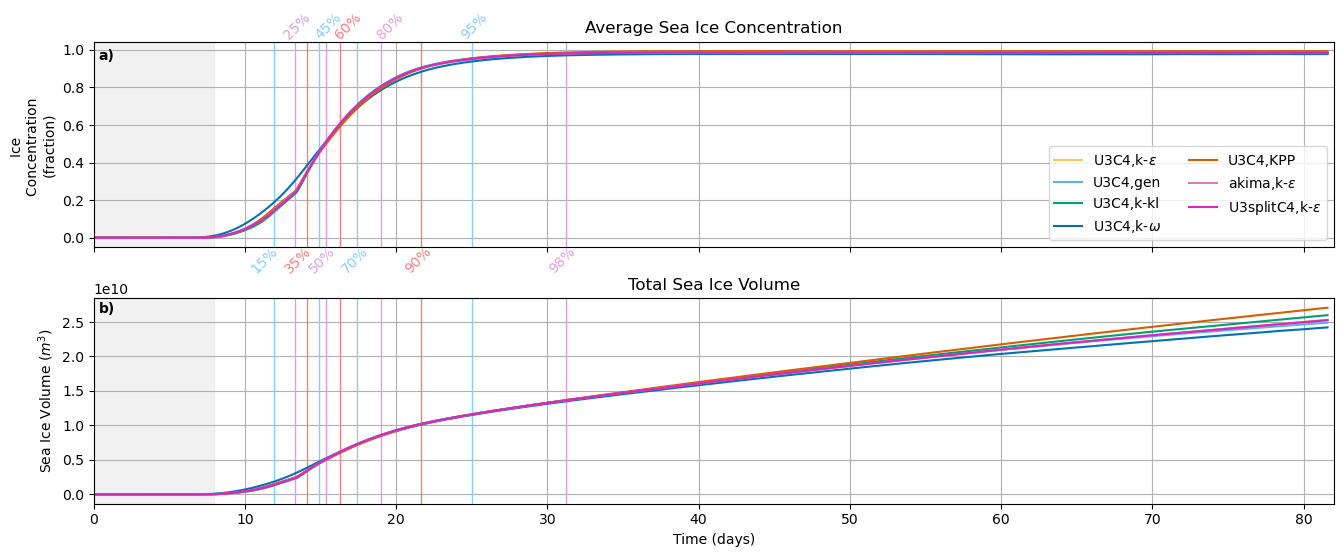

In [38]:
# Plot sea ice time series with where these lines are so 
# that it is clear for the other plots (and to check myself)

# Make the figure
fig, ax = plt.subplots(2, figsize=(16,6))

# Add the lines for different average sea ice concentrations 
for r in range(2):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_25_perc], color='plum', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightcoral', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='plum', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightcoral', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_80_perc], color='plum', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightcoral', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='plum', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')




# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[0].legend(ncols=2) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()

# Manually label the lines with their percentages
#fig.text(0.228, 0.505, '10%', color='lightskyblue')
fig.text(0.222, 0.494, '15%', color='lightskyblue', rotation=45)
fig.text(0.242, 0.885, '25%', color='plum', rotation=45)
fig.text(0.243, 0.494, '35%', color='lightcoral', rotation=45)
fig.text(0.262, 0.885, '45%', color='lightskyblue', rotation=45)
fig.text(0.258, 0.494, '50%', color='plum', rotation=45)
fig.text(0.274, 0.885, '60%', color='lightcoral', rotation=45)
fig.text(0.278, 0.494, '70%', color='lightskyblue', rotation=45)
fig.text(0.300, 0.885, '80%', color='plum', rotation=45)
fig.text(0.318, 0.494, '90%', color='lightcoral', rotation=45)
fig.text(0.353, 0.885, '95%', color='lightskyblue', rotation=45)
fig.text(0.408, 0.494, '98%', color='plum', rotation=45)

# Add subplot labels
fig.text(0.128, 0.850, 'a)', color='black', weight='bold')
fig.text(0.128, 0.428, 'b)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
#ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

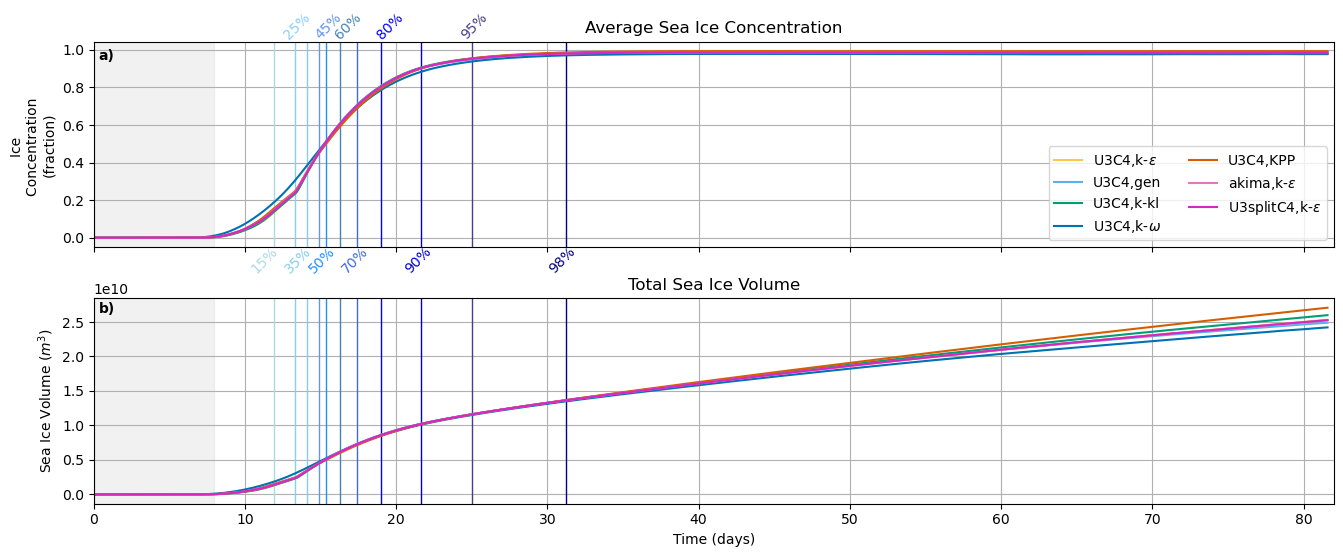

In [39]:
# Same as above but with gradient of grays for concentrations 
grays = [
    "#F5F5F5",  # White Smoke (very light)
    "#D3D3D3",  # Light Gray
    "#C0C0C0",  # Silver
    "#A9A9A9",  # Dark Gray
    "#808080",  # Gray (standard middle gray)
    "#696969",  # Dim Gray
    "#404040",  # Very dark gray
    "#2F4F4F",  # Dark Slate Gray
    "#000000"   # Black (the darkest "shade")
]

blues = [
    'lightblue', 'lightskyblue', 'skyblue', 'cornflowerblue', 'dodgerblue',
    'steelblue', 'royalblue', 'blue',
    'mediumblue', 'darkslateblue', 'navy', 'midnightblue'
]


# Make the figure
fig, ax = plt.subplots(2, figsize=(16,6))

# Add the lines for different average sea ice concentrations 
for r in range(2):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color=blues[0], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_25_perc], color=blues[1], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_35_perc], color=blues[2], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_45_perc], color=blues[3], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color=blues[4], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_60_perc], color=blues[5], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_70_perc], color=blues[6], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_80_perc], color=blues[7], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color=blues[8], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_95_perc], color=blues[9], linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color=blues[10], linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')




# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[0].legend(ncols=2) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()

# Manually label the lines with their percentages
#fig.text(0.228, 0.505, '10%', colorblues[]ue')
fig.text(0.222, 0.494, '15%', color=blues[0], rotation=45)
fig.text(0.242, 0.885, '25%', color=blues[1], rotation=45)
fig.text(0.243, 0.494, '35%', color=blues[2], rotation=45)
fig.text(0.262, 0.885, '45%', color=blues[3], rotation=45)
fig.text(0.258, 0.494, '50%', color=blues[4], rotation=45)
fig.text(0.274, 0.885, '60%', color=blues[5], rotation=45)
fig.text(0.278, 0.494, '70%', color=blues[6], rotation=45)
fig.text(0.300, 0.885, '80%', color=blues[7], rotation=45)
fig.text(0.318, 0.494, '90%', color=blues[8], rotation=45)
fig.text(0.353, 0.885, '95%', color=blues[9], rotation=45)
fig.text(0.408, 0.494, '98%', color=blues[10], rotation=45)

# Add subplot labels
fig.text(0.128, 0.850, 'a)', color='black', weight='bold')
fig.text(0.128, 0.428, 'b)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
#ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

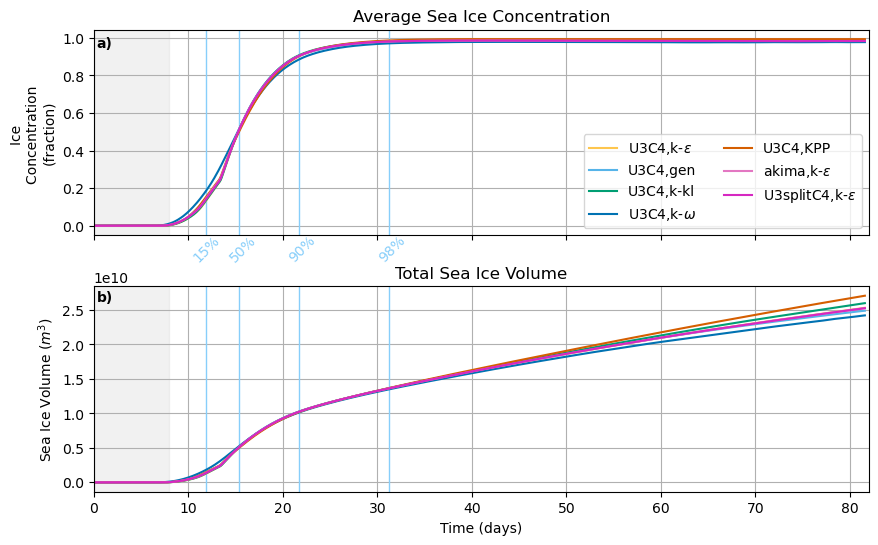

In [40]:
# MAke this plot again but less percentages and all 
# the same color (to help with future plots)

# Make the figure
fig, ax = plt.subplots(2, figsize=(10,6))

# Add the lines for different average sea ice concentrations 
for r in range(2):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')




# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[0].legend(ncols=2) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()

# Manually label the lines with their percentages
#fig.text(0.228, 0.505, '10%', colorblues[]ue')
fig.text(0.222, 0.494, '15%', color='lightskyblue', rotation=45)
#fig.text(0.242, 0.885, '25%', color='lightskyblue', rotation=45)
#fig.text(0.243, 0.494, '35%', color='lightskyblue', rotation=45)
#fig.text(0.262, 0.885, '45%', color='lightskyblue', rotation=45)
fig.text(0.258, 0.494, '50%', color='lightskyblue', rotation=45)
#fig.text(0.274, 0.885, '60%', color='lightskyblue', rotation=45)
#fig.text(0.278, 0.494, '70%', color='lightskyblue', rotation=45)
#fig.text(0.300, 0.885, '80%', color='lightskyblue', rotation=45)
fig.text(0.318, 0.494, '90%', color='lightskyblue', rotation=45)
#fig.text(0.353, 0.885, '95%', color='lightskyblue', rotation=45)
fig.text(0.408, 0.494, '98%', color='lightskyblue', rotation=45)

# Add subplot labels
fig.text(0.128, 0.850, 'a)', color='black', weight='bold')
fig.text(0.128, 0.428, 'b)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
#ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

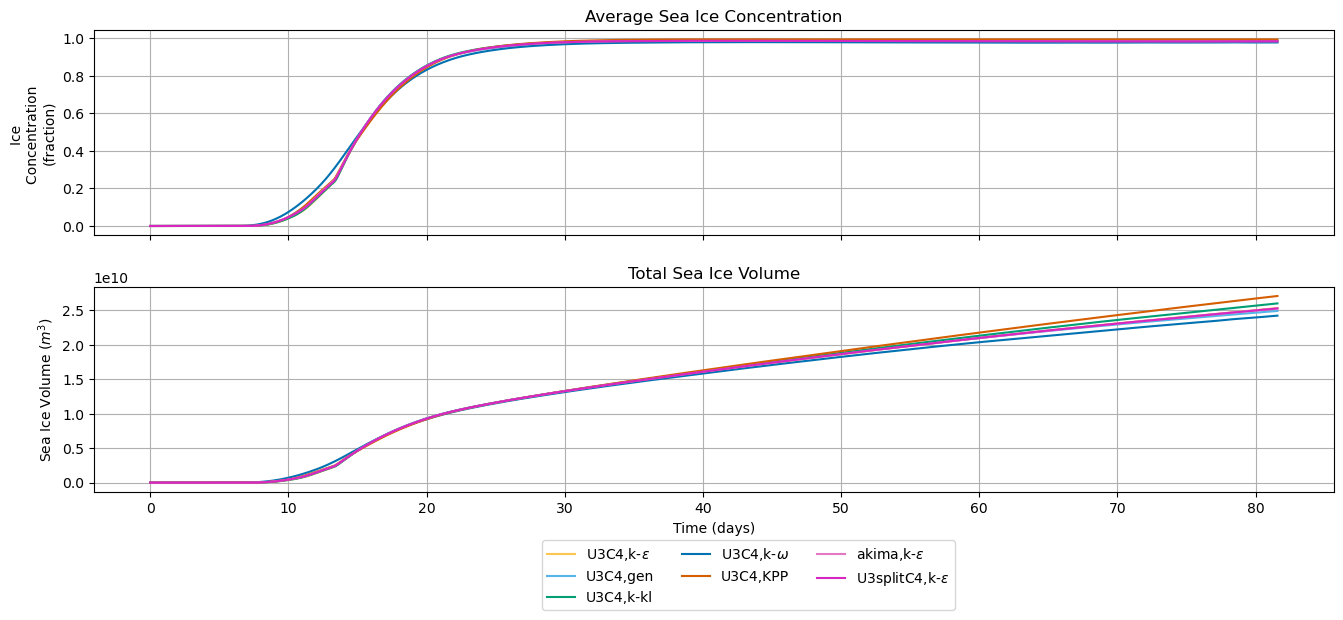

In [41]:
# Plot just sea ice conditions by themselves

# Make the figure
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# Add vertical lines for days in snapshots


# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')



**Calculate and Save Surface Heat Fluxes**

In [43]:
# Make the same plot as the fancy sea ice one
# above but add a panel for surface heat fluxes

# Get surface heat fluxes from the output, take the total 
# in the boxed region for each time step
tot_shflux_u3c4_keps = ds_ice_u3c4_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3c4_keps_no_ice = ds_ice_u3c4_keps_no_ice.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3c4_gen = ds_ice_u3c4_gen.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3c4_kkl = ds_ice_u3c4_kkl.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3c4_komega = ds_ice_u3c4_komega.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3c4_kpp = ds_ice_u3c4_kpp.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_akima_keps = ds_ice_akima_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()
tot_shflux_u3splitc4_keps = ds_ice_u3splitc4_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('eta_rho', 'xi_rho')).compute()


KeyboardInterrupt: 

In [ ]:
# Do the same as above but the average instead in
# case that's more informative
avg_shflux_u3c4_keps = ds_ice_u3c4_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3c4_keps_no_ice = ds_ice_u3c4_keps_no_ice.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3c4_gen = ds_ice_u3c4_gen.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3c4_kkl = ds_ice_u3c4_kkl.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3c4_komega = ds_ice_u3c4_komega.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3c4_kpp = ds_ice_u3c4_kpp.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_akima_keps = ds_ice_akima_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()
avg_shflux_u3splitc4_keps = ds_ice_u3splitc4_keps.shflux.sel(eta_rho=eta_slice, xi_rho=xi_slice).mean(dim=('eta_rho', 'xi_rho')).compute()


In [ ]:
# I think maybe save these to a netcdf since I think it is going to take a while
# and that will make it easier to plot later?

# Save the data to a netcdf

# Variables to save: N2, n2_bins, n2_pdf, M2, m2_bins, m2_pdf

roms_shflux = xr.Dataset(
    data_vars=dict(
        tot_shflux_u3c4_keps=(['ocean_time'], tot_shflux_u3c4_keps[:980].values),
        avg_shflux_u3c4_keps=(['ocean_time'], avg_shflux_u3c4_keps[:980].values),
        tot_shflux_u3c4_keps_no_ice=(['ocean_time'], tot_shflux_u3c4_keps_no_ice[:980].values),
        avg_shflux_u3c4_keps_no_ice=(['ocean_time'], avg_shflux_u3c4_keps_no_ice[:980].values),
        tot_shflux_u3c4_gen=(['ocean_time'], tot_shflux_u3c4_gen[:980].values),
        avg_shflux_u3c4_gen=(['ocean_time'], avg_shflux_u3c4_gen[:980].values),
        tot_shflux_u3c4_kkl=(['ocean_time'], tot_shflux_u3c4_kkl[:980].values),
        avg_shflux_u3c4_kkl=(['ocean_time'], avg_shflux_u3c4_kkl[:980].values),
        tot_shflux_u3c4_komega=(['ocean_time'], tot_shflux_u3c4_komega[:980].values),
        avg_shflux_u3c4_komega=(['ocean_time'], avg_shflux_u3c4_komega[:980].values),
        tot_shflux_u3c4_kpp=(['ocean_time'], tot_shflux_u3c4_kpp[:980].values),
        avg_shflux_u3c4_kpp=(['ocean_time'], avg_shflux_u3c4_kpp[:980].values),
        tot_shflux_akima_keps=(['ocean_time'], tot_shflux_akima_keps[:980].values),
        avg_shflux_akima_keps=(['ocean_time'], avg_shflux_akima_keps[:980].values),
        tot_shflux_u3splitc4_keps=(['ocean_time'], tot_shflux_u3splitc4_keps[:980].values),
        avg_shflux_u3splitc4_keps=(['ocean_time'], avg_shflux_u3splitc4_keps[:980].values),
    ),
    coords=dict(
        ocean_time=('ocean_time', ds_ice_u3c4_keps.ocean_time[:980].values),
    ),
    attrs=dict(description='Time-series of surface heat flux (total and average in box) of ROMS output from 2-hourly model outputs')
)

# Add attributes to the 'temperature' data variable
roms_shflux['tot_shflux_u3c4_keps'].attrs['long_name'] = 'total surface heat flux in box for u3c4 keps run'
roms_shflux['tot_shflux_u3c4_keps'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_keps'].attrs['long_name'] = 'average surface heat flux in box for u3c4 keps run'
roms_shflux['avg_shflux_u3c4_keps'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3c4_keps_no_ice'].attrs['long_name'] = 'total surface heat flux in box for u3c4 keps, no ice run'
roms_shflux['tot_shflux_u3c4_keps_no_ice'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_keps_no_ice'].attrs['long_name'] = 'average surface heat flux in box for u3c4 keps, no ice run'
roms_shflux['avg_shflux_u3c4_keps_no_ice'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3c4_gen'].attrs['long_name'] = 'total surface heat flux in box for u3c4 gen run'
roms_shflux['tot_shflux_u3c4_gen'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_gen'].attrs['long_name'] = 'average surface heat flux in box for u3c4 gen run'
roms_shflux['avg_shflux_u3c4_gen'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3c4_kkl'].attrs['long_name'] = 'total surface heat flux in box for u3c4 kkl run'
roms_shflux['tot_shflux_u3c4_kkl'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_kkl'].attrs['long_name'] = 'average surface heat flux in box for u3c4 kkl run'
roms_shflux['avg_shflux_u3c4_kkl'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3c4_komega'].attrs['long_name'] = 'total surface heat flux in box for u3c4 komega run'
roms_shflux['tot_shflux_u3c4_komega'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_komega'].attrs['long_name'] = 'average surface heat flux in box for u3c4 komega run'
roms_shflux['avg_shflux_u3c4_komega'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3c4_kpp'].attrs['long_name'] = 'total surface heat flux in box for u3c4 kpp run'
roms_shflux['tot_shflux_u3c4_kpp'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3c4_kpp'].attrs['long_name'] = 'average surface heat flux in box for u3c4 kpp run'
roms_shflux['avg_shflux_u3c4_kpp'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_akima_keps'].attrs['long_name'] = 'total surface heat flux in box for akima keps run'
roms_shflux['tot_shflux_akima_keps'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_akima_keps'].attrs['long_name'] = 'average surface heat flux in box for akima keps run'
roms_shflux['avg_shflux_akima_keps'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['tot_shflux_u3splitc4_keps'].attrs['long_name'] = 'total surface heat flux in box for u3splitc4 keps run'
roms_shflux['tot_shflux_u3splitc4_keps'].attrs['units'] = '($W m^{-2}$)'
roms_shflux['avg_shflux_u3splitc4_keps'].attrs['long_name'] = 'average surface heat flux in box for u3splitc4 keps run'
roms_shflux['avg_shflux_u3splitc4_keps'].attrs['units'] = '($W m^{-2}$)'


# Save to a netcdf
#roms_shflux.to_netcdf('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_tot_avg_shflux_all_runs_001.nc')


**Load In & Plot Surface Heat Fluxes**

In [42]:
# Load in the surface heat fluxes
roms_shflux = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_tot_avg_shflux_all_runs_001.nc')

[]

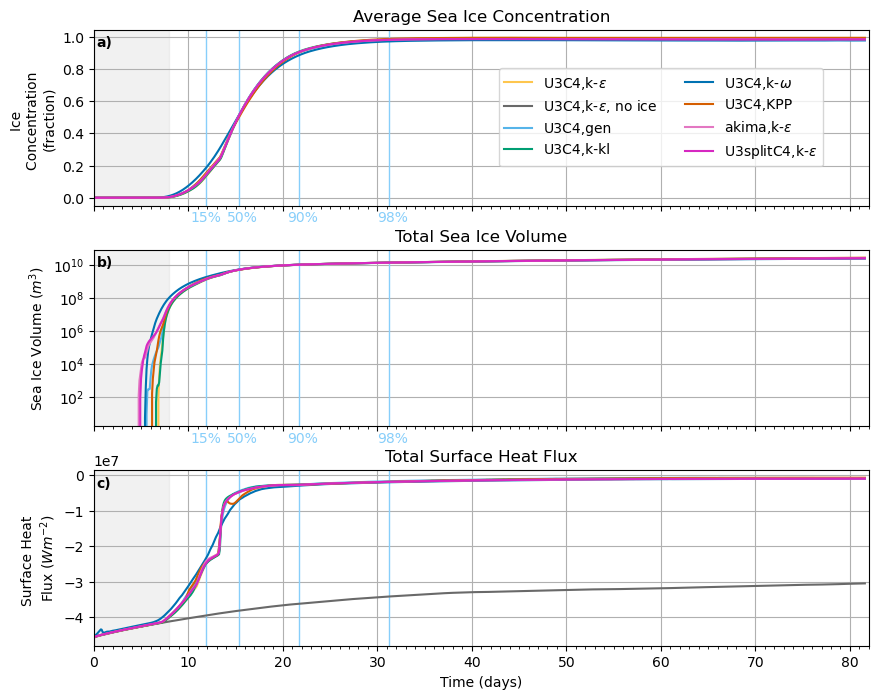

In [43]:
# Make a plot with total surface heat flux

# Make the figure
fig, ax = plt.subplots(3, figsize=(10,8))

# Add the lines for different average sea ice concentrations 
for r in range(3):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')


# Plot total surface heat flux
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_shflux.tot_shflux_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
ax[2].plot(time_u3c4_keps_no_ice[:980], roms_shflux.tot_shflux_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$, no ice')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_shflux.tot_shflux_u3c4_gen[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_shflux.tot_shflux_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_shflux.tot_shflux_u3c4_komega[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_shflux.tot_shflux_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_shflux.tot_shflux_akima_keps[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_shflux.tot_shflux_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# Label plot
ax[2].set_ylabel('Surface Heat \nFlux ($W m^{-2}$)')
ax[2].set_title(r'Total Surface Heat Flux')
ax[2].set_xlabel('Time (days)')


# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[2].legend(ncols=2, bbox_to_anchor=(0.95, 3.32)) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Manually label the lines with their percentages
# ax[0]
fig.text(0.222, 0.640, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.640, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.640, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.640, '98%', color='lightskyblue', rotation=0)
# ax[1]
fig.text(0.222, 0.364, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.364, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.364, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.364, '98%', color='lightskyblue', rotation=0)

# Add subplot labels
fig.text(0.128, 0.859, 'a)', color='black', weight='bold')
fig.text(0.128, 0.584, 'b)', color='black', weight='bold')
fig.text(0.128, 0.308, 'c)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
ax[1].semilogy()
#ax[2].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')


[]

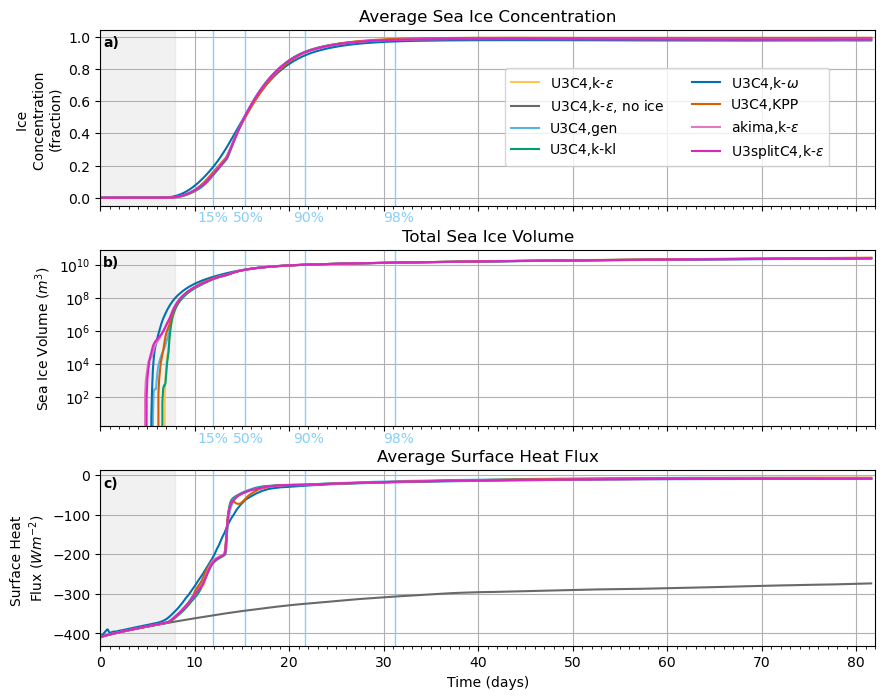

In [44]:
# Make a plot with average surface heat flux 

# Make the figure
fig, ax = plt.subplots(3, figsize=(10,8))

# Add the lines for different average sea ice concentrations 
for r in range(3):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')


# Plot total surface heat flux
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_shflux.avg_shflux_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
ax[2].plot(time_u3c4_keps_no_ice[:980], roms_shflux.avg_shflux_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$, no ice')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_shflux.avg_shflux_u3c4_gen[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_shflux.avg_shflux_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_shflux.avg_shflux_u3c4_komega[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_shflux.avg_shflux_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_shflux.avg_shflux_akima_keps[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_shflux.avg_shflux_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# Label plot
ax[2].set_ylabel('Surface Heat \nFlux ($W m^{-2}$)')
ax[2].set_title(r'Average Surface Heat Flux')
ax[2].set_xlabel('Time (days)')


# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[2].legend(ncols=2, bbox_to_anchor=(0.95, 3.32)) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Manually label the lines with their percentages
# ax[0]
fig.text(0.222, 0.640, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.640, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.640, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.640, '98%', color='lightskyblue', rotation=0)
# ax[1]
fig.text(0.222, 0.364, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.364, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.364, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.364, '98%', color='lightskyblue', rotation=0)

# Add subplot labels
fig.text(0.128, 0.859, 'a)', color='black', weight='bold')
fig.text(0.128, 0.584, 'b)', color='black', weight='bold')
fig.text(0.128, 0.308, 'c)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')


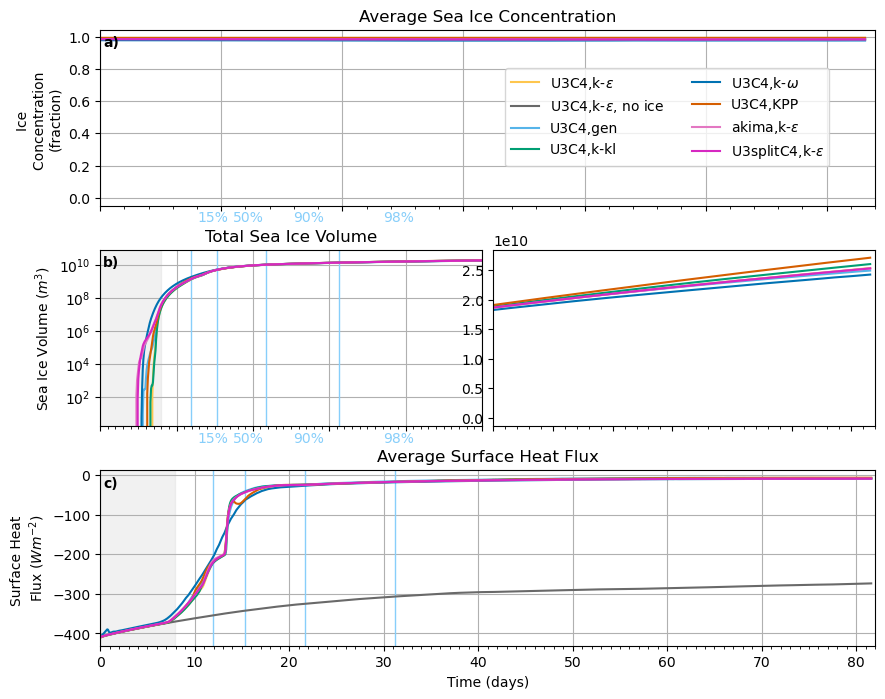

In [45]:
# ChatGPT help
# Make the same plots as above but include 
# linear part of back half of sea ice volume 
# to show how it diverges towards end of run
# and add ticks for each day

# Make the figure
fig = plt.figure(figsize=(10, 8))

# Use gridspec to help with axes
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.25)

# Top and bottom panels 
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[2])

# Middle panel split into linear + log
gs_mid = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.03)

ax_mid_log = fig.add_subplot(gs_mid[0])
ax_mid_lin = fig.add_subplot(gs_mid[1], sharex=ax_top)

ax = [ax_top, ax_mid_log, ax_bot]
# Add the lines for different average sea ice concentrations 
for r in range(3):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax_top.plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 Gen
ax_top.plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax_top.plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax_top.plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax_top.plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax_top.plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax_top.plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax_top.set_ylabel('Ice \nConcentration \n(fraction)')
ax_top.set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# -- Log scale --
# U3C4 K-epsilon Ice
ax_mid_log.plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax_mid_log.plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax_mid_log.plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax_mid_log.plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax_mid_log.plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax_mid_log.plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax_mid_log.plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# -- Linear scale --
# U3C4 K-epsilon Ice
ax_mid_lin.plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax_mid_lin.plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax_mid_lin.plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax_mid_lin.plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax_mid_lin.plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax_mid_lin.plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax_mid_lin.plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Split the axes
x_break = 50
ax_mid_log.set_xlim(0, x_break)
ax_mid_lin.set_xlim(x_break, 82)
ax_mid_log.set_yscale('log')
# Label plot
ax_mid_log.set_ylabel('Sea Ice Volume ($m^{3}$)')
ax_mid_log.set_title(r'Total Sea Ice Volume')


# Plot total surface heat flux
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax_bot.plot(time_u3c4_keps[:980], roms_shflux.avg_shflux_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
ax_bot.plot(time_u3c4_keps_no_ice[:980], roms_shflux.avg_shflux_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$, no ice')
# U3C4 Gen
ax_bot.plot(time_u3c4_gen[:980], roms_shflux.avg_shflux_u3c4_gen[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax_bot.plot(time_u3c4_kkl[:980], roms_shflux.avg_shflux_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax_bot.plot(time_u3c4_komega[:980], roms_shflux.avg_shflux_u3c4_komega[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax_bot.plot(time_u3c4_kpp[:980], roms_shflux.avg_shflux_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax_bot.plot(time_akima_keps[:980], roms_shflux.avg_shflux_akima_keps[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# U3splitC4 k-epsilon
ax_bot.plot(time_u3splitc4_keps[:980], roms_shflux.avg_shflux_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# Label plot
ax_bot.set_ylabel('Surface Heat \nFlux ($W m^{-2}$)')
ax_bot.set_title(r'Average Surface Heat Flux')
ax_bot.set_xlabel('Time (days)')


# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax_top.set_xticklabels('')
ax[1].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax_bot.legend(ncols=2, bbox_to_anchor=(0.95, 3.32)) #, bbox_to_anchor=(0.70, -0.2))
ax_top.grid()
ax[1].grid()
ax_bot.grid()

# Manually label the lines with their percentages
# ax[0]
fig.text(0.222, 0.640, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.640, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.640, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.640, '98%', color='lightskyblue', rotation=0)
# ax[1]
fig.text(0.222, 0.364, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.364, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.364, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.364, '98%', color='lightskyblue', rotation=0)

# Add subplot labels
fig.text(0.128, 0.859, 'a)', color='black', weight='bold')
fig.text(0.128, 0.584, 'b)', color='black', weight='bold')
fig.text(0.128, 0.308, 'c)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
#ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')


[]

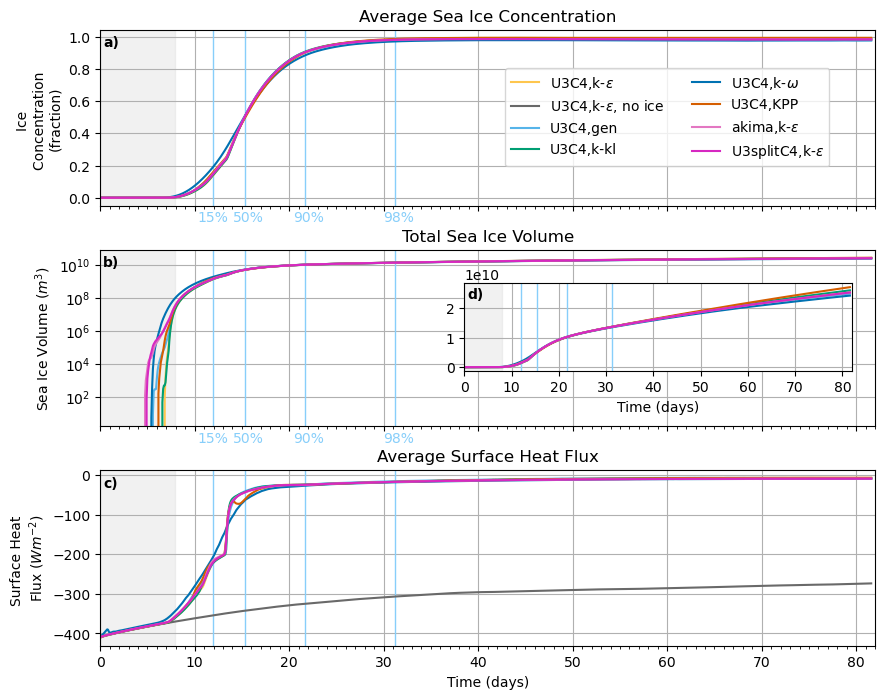

In [46]:
# Try a version with an inset 

# Make the figure
fig, ax = plt.subplots(3, figsize=(10,8))

# Add the lines for different average sea ice concentrations 
for r in range(3):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_keps_avg, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_gen_avg, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kkl_avg, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_komega_avg, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_conc_u3c4_kpp_avg, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_conc_akima_keps_avg, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_conc_hsimt_keps_avg, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_conc_mpdata_keps_avg, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_conc_u3splitc4_keps_avg, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_ice_vol_conc_ds.ice_vol_hsimt_keps_tot, color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_ice_vol_conc_ds.ice_vol_mpdata_keps_tot, color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# Label plot
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Do inset of linear sea ice volume
ax_inset = ax[1].inset_axes([0.47, 0.31, 0.5, 0.5])
# Add gridlines
ax_inset.grid()
# Set x-lim
ax_inset.set_xlim(0,82)
# Put a vertical line for the different average ice conc across runs
ax_inset.axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
ax_inset.axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
ax_inset.axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
ax_inset.axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
# colors I like: plum, lightpink, lightskyblue, 
# Shade the period where sea ice is forming near the coast and approaching the box
# near land and about to reach the box
ax_inset.axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
# Plot ice volume
ax_inset.plot(time_u3c4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot, color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax_inset.plot(time_u3c4_gen[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot, color=mixing_colors_all[2], label=r'U3C4,gen')
ax_inset.plot(time_u3c4_kkl[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot, color=mixing_colors_all[3], label=r'U3C4,k-kl')
ax_inset.plot(time_u3c4_komega[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot, color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
ax_inset.plot(time_u3c4_kpp[:980], roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot, color=mixing_colors_all[5], label=r'U3C4,KPP')
ax_inset.plot(time_akima_keps[:980], roms_ice_vol_conc_ds.ice_vol_akima_keps_tot, color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
ax_inset.plot(time_u3splitc4_keps[:980], roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot, color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
ax_inset.set_xlabel('Time (days)')


# Plot total surface heat flux
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_shflux.avg_shflux_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
# U3C4 K-epsilon No ice
ax[2].plot(time_u3c4_keps_no_ice[:980], roms_shflux.avg_shflux_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$, no ice')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_shflux.avg_shflux_u3c4_gen[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_shflux.avg_shflux_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_shflux.avg_shflux_u3c4_komega[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_shflux.avg_shflux_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_shflux.avg_shflux_akima_keps[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_shflux.avg_shflux_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
# Label plot
ax[2].set_ylabel('Surface Heat \nFlux ($W m^{-2}$)')
ax[2].set_title(r'Average Surface Heat Flux')
ax[2].set_xlabel('Time (days)')


# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
#ax[1].legend(ncols=3) #, bbox_to_anchor=(0.70, -0.2))
ax[2].legend(ncols=2, bbox_to_anchor=(0.95, 3.32)) #, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Manually label the lines with their percentages
# ax[0]
fig.text(0.222, 0.640, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.640, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.640, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.640, '98%', color='lightskyblue', rotation=0)
# ax[1]
fig.text(0.222, 0.364, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.364, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.364, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.364, '98%', color='lightskyblue', rotation=0)

# Add subplot labels
fig.text(0.128, 0.859, 'a)', color='black', weight='bold')
fig.text(0.128, 0.584, 'b)', color='black', weight='bold')
fig.text(0.128, 0.308, 'c)', color='black', weight='bold')
fig.text(0.492, 0.544, 'd)', color='black', weight='bold')

fig.subplots_adjust(hspace=0.25)


# Save one version with log scale for volume and one without
# ax[0].semilogy()
ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')


**Mixing Plots With Sea Ice Info**

[]

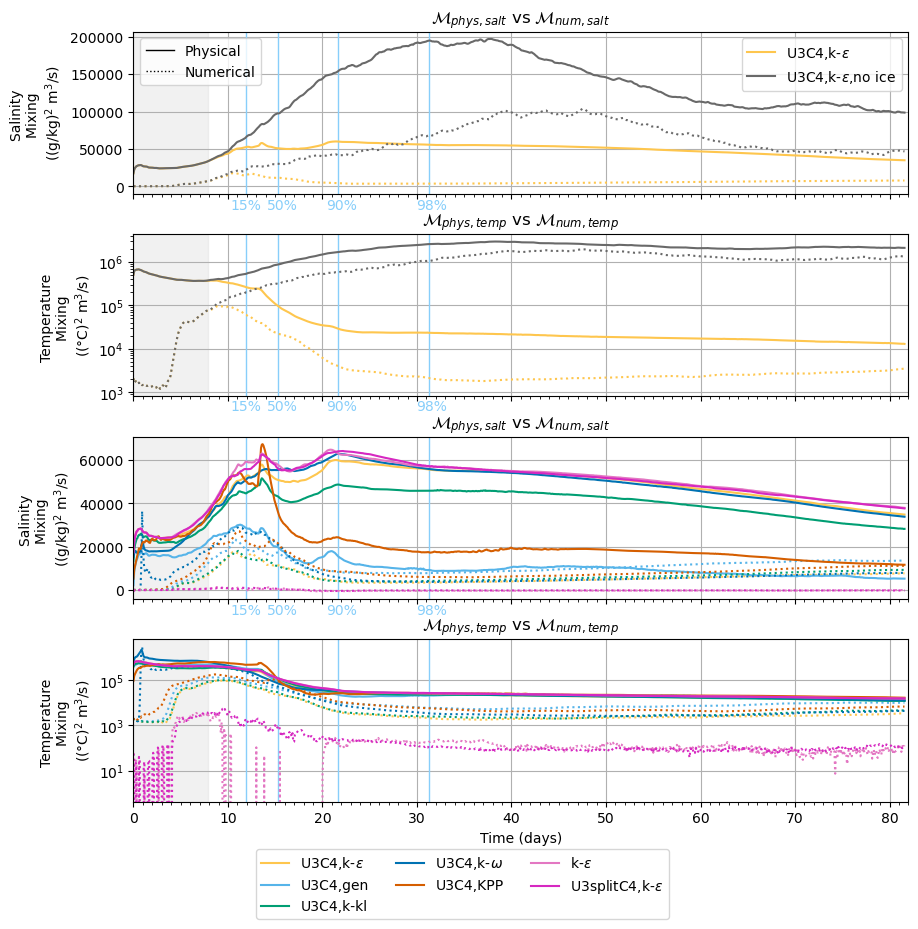

In [47]:
# Do all of the things stated above that we are trying to dooo

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(4, figsize=(10,10))

# Add vertical lines for days in snapshots where sea ice concentrations 
# are different values (and annotate with the concentraiton)
# Add the lines for different average sea ice concentrations 
for r in range(4):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))


# Plot ice vs no ice - salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$,no ice')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], linestyle=':')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot ice vs. no ice - temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle=':')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphyt, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon,no ice}$')
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,,no ice}$', linestyle=':')
# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Plot all ice salinity mixing 
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'k-$\epsilon$')
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle=':')
# u3splitc4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], linestyle=':')

# Label plot
# ax[0].set_xlabel('Time')
ax[2].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[2].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')


# Plot all ice temperature mixing 
# U3C4 K-epsilon Ice
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle=':')
# mpdata k-epsilon
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle=':')
# U3splitC4 k-epsilon
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle=':')
# Label plot
ax[3].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[3].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')



# Label plot
ax[3].set_xlabel('Time (days)')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[2].set_xticklabels('')
ax[2].legend(ncols=3, bbox_to_anchor=(0.70, -1.5))
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle=':')  
]
legend2 = ax[0].legend(custom_lines, ['Physical', 'Numerical'], loc='upper left')
ax[0].add_artist(legend2)
ax[0].legend(loc='upper right')


fig.subplots_adjust(hspace=0.25)

# Manually label the lines with their percentages
# Top panel
fig.text(0.222, 0.702, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.702, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.702, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.702, '98%', color='lightskyblue', rotation=0)
# Middle 
fig.text(0.222, 0.501, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.501, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.501, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.501, '98%', color='lightskyblue', rotation=0)
# Second to last
fig.text(0.222, 0.297, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.297, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.297, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.297, '98%', color='lightskyblue', rotation=0)
# Bottom?


# ax[0].semilogy()
ax[1].semilogy()
ax[3].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')


Text(0.883, 0.304, 'd)')

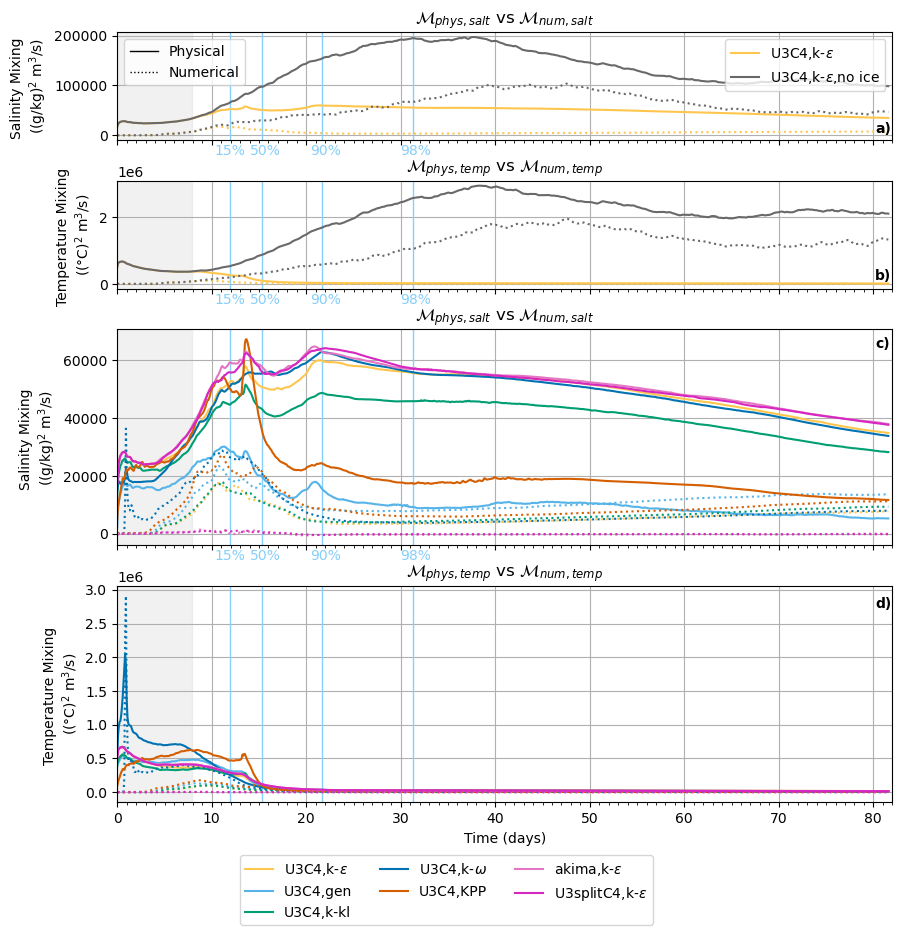

In [48]:
# Same as above but with different heights for axes
# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(4, figsize=(10,10), gridspec_kw={'height_ratios': [0.5, 0.5, 1, 1]})

# Add vertical lines for days in snapshots where sea ice concentrations 
# are different values (and annotate with the concentraiton)
# Add the lines for different average sea ice concentrations 
for r in range(4):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))


# Plot ice vs no ice - salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$,no ice')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], linestyle=':')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity Mixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot ice vs. no ice - temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle=':')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphyt, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon,no ice}$')
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,,no ice}$', linestyle=':')
# Label plot
ax[1].set_ylabel('Temperature Mixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Plot all ice salinity mixing 
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle=':')
# u3splitc4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], linestyle=':')

# Label plot
# ax[0].set_xlabel('Time')
ax[2].set_ylabel('Salinity Mixing \n((g/kg)$^2$ m$^3$/s)')
ax[2].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')


# Plot all ice temperature mixing 
# U3C4 K-epsilon Ice
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle=':')
# mpdata k-epsilon
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle=':')
# U3splitC4 k-epsilon
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle=':')
# Label plot
ax[3].set_ylabel('Temperature Mixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[3].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')



# Label plot
ax[3].set_xlabel('Time (days)')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[2].set_xticklabels('')
ax[2].legend(ncols=3, bbox_to_anchor=(0.70, -1.40)) #(0.70, -1.40), (0.50, -1.80)
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle=':')  
]
legend2 = ax[0].legend(custom_lines, ['Physical', 'Numerical'], loc='upper left')
ax[0].add_artist(legend2)
ax[0].legend(loc='upper right')


fig.subplots_adjust(hspace=0.25)

# Manually label the lines with their percentages
# Top panel
fig.text(0.222, 0.757, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.757, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.757, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.757, '98%', color='lightskyblue', rotation=0)
# Middle 
fig.text(0.222, 0.608, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.608, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.608, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.608, '98%', color='lightskyblue', rotation=0)
# Second to last
fig.text(0.222, 0.352, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.352, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.352, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.352, '98%', color='lightskyblue', rotation=0)
# Bottom?


# ax[0].semilogy()
#ax[0].semilogy()
#ax[1].semilogy()
#ax[2].semilogy()
#ax[3].semilogy()

# Add subplot labels
fig.text(0.883, 0.779, 'a)', color='black', weight='bold')
fig.text(0.883, 0.632, 'b)', color='black', weight='bold')
# Log scale plots
# fig.text(0.883, 0.374, 'c)', color='black', weight='bold')
# fig.text(0.883, 0.116, 'd)', color='black', weight='bold')
# lin scale plots
fig.text(0.883, 0.564, 'c)', color='black', weight='bold')
fig.text(0.883, 0.304, 'd)', color='black', weight='bold')

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

In [49]:
# Load in the time series of volumes in the box
roms_vols = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/box_volumes_all_runs.nc')

In [50]:
roms_vols.box_vol_akima_keps[0].values

array(8.29371544e+12)

In [51]:
print('time for day 10: ', time_u3c4_keps[108])
print('time for day 12: ', time_u3c4_keps[132])
print('time for day 18: ', time_u3c4_keps[204])
print('time for day 20: ', time_u3c4_keps[240])
time_idx_10days = 108
time_idx_12days = 132
time_idx_18days = 204
time_idx_21days = 240

time for day 10:  9.0
time for day 12:  11.0
time for day 18:  17.0
time for day 20:  20.0


Text(0.883, 0.304, 'd)')

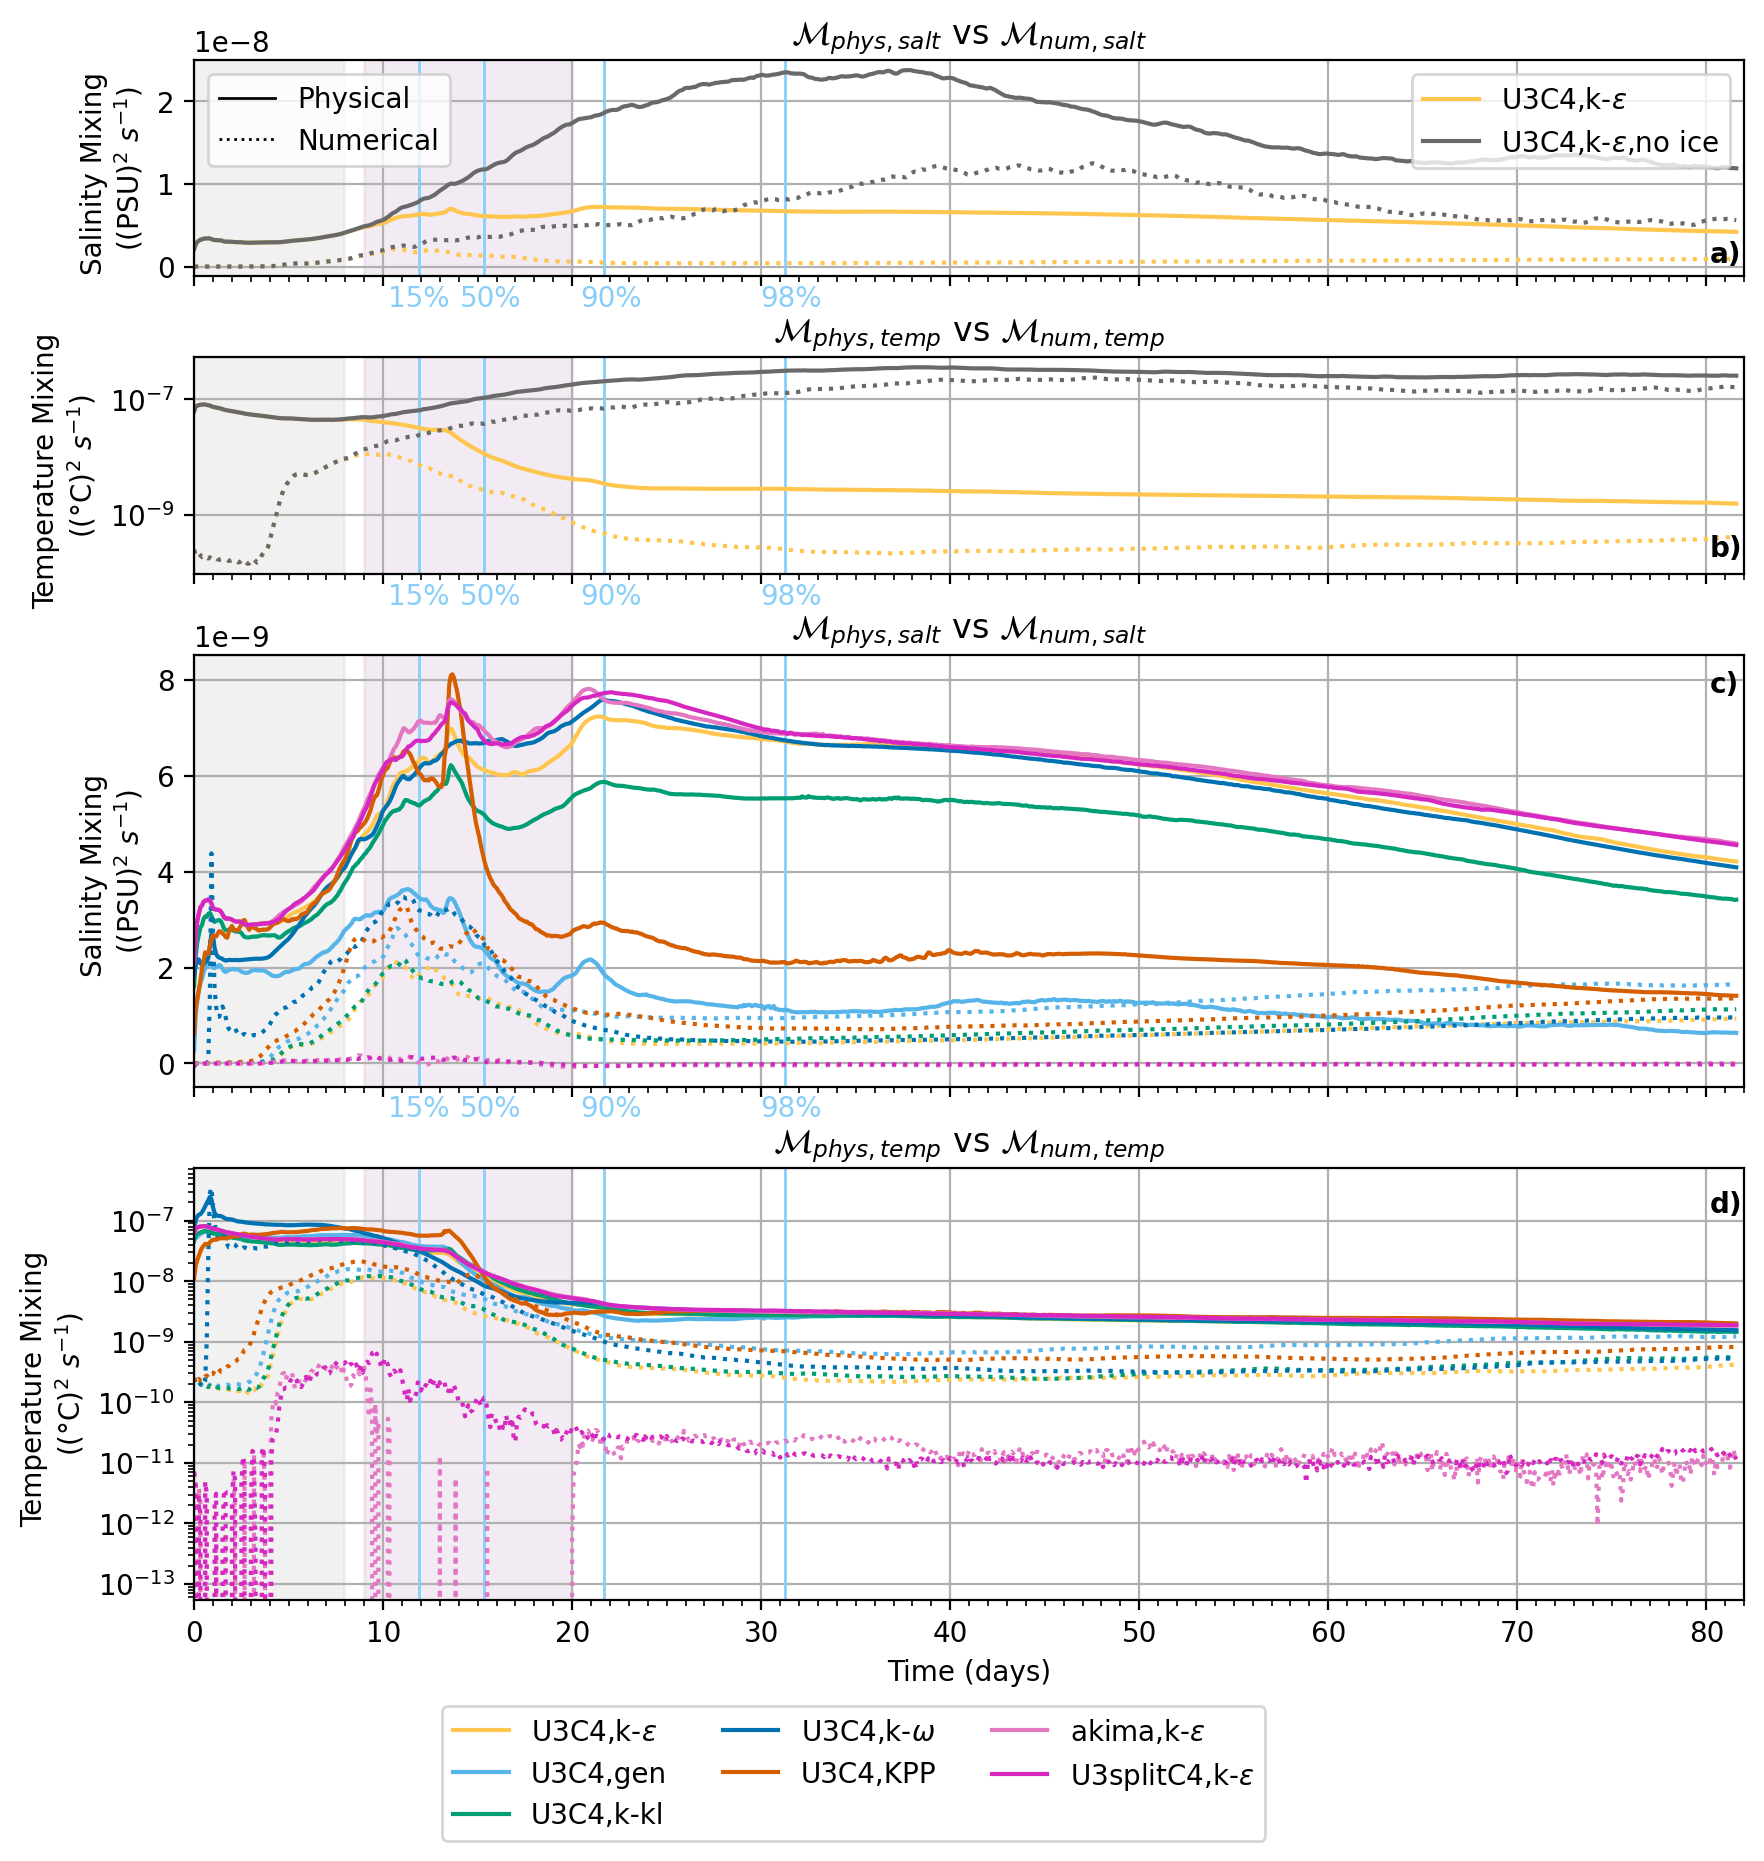

In [53]:
# Make another version of this plot that has volume-averaged 
# (rather than volume-integrated) mixing (so divide by the volumes 
# from above) 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(4, figsize=(10,10), dpi=200,
                       gridspec_kw={'height_ratios': [0.5, 0.5, 1, 1]})

# Add vertical lines for days in snapshots where sea ice concentrations 
# are different values (and annotate with the concentraiton)
# Add the lines for different average sea ice concentrations 
for r in range(4):
    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(time_u3c4_keps[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, time_u3c4_keps[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)
    # Add tick for each day
    ax[r].xaxis.set_minor_locator(MultipleLocator(1))
    # Add shading for when peak EKE occurs
    ax[r].axvspan(time_u3c4_keps[time_idx_10days], time_u3c4_keps[time_idx_21days], color='thistle', alpha=0.3)


# Plot ice vs no ice - salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphys/roms_vols.box_vol_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'U3C4,k-$\epsilon$,no ice')
ax[0].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv/roms_vols.box_vol_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], linestyle=':')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity Mixing \n((PSU)$^2$ $s^{-1}$)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot ice vs. no ice - temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle=':')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980]/roms_vols.box_vol_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon,no ice}$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_keps_no_ice[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,,no ice}$', linestyle=':')
# Label plot
ax[1].set_ylabel('Temperature Mixing \n(($\degree$C)$^2$ $s^{-1}$)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Plot all ice salinity mixing 
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], label=r'U3C4,k-$\epsilon$')
ax[2].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980]/roms_vols.box_vol_u3c4_gen[:980], color=mixing_colors_all[2], label=r'U3C4,gen')
ax[2].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_gen[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980]/roms_vols.box_vol_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'U3C4,k-kl')
ax[2].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_kkl[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980]/roms_vols.box_vol_u3c4_komega[:980], color=mixing_colors_all[4], label=r'U3C4,k-$\omega$')
ax[2].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_komega[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980]/roms_vols.box_vol_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'U3C4,KPP')
ax[2].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980]/roms_vols.box_vol_u3c4_kpp[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980]/roms_vols.box_vol_akima_keps[:980], color=mixing_colors_all[6], label=r'akima,k-$\epsilon$')
ax[2].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980]/roms_vols.box_vol_akima_keps[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[2].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[2].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle=':')
# u3splitc4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980]/roms_vols.box_vol_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'U3splitC4,k-$\epsilon$')
ax[2].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980]/roms_vols.box_vol_u3splitc4_keps[:980], color=mixing_colors_all[9], linestyle=':')

# Label plot
# ax[0].set_xlabel('Time')
ax[2].set_ylabel('Salinity Mixing \n((PSU)$^2$ $s^{-1}$)')
ax[2].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')


# Plot all ice temperature mixing 
# U3C4 K-epsilon Ice
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[3].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_keps[:980], color=mixing_colors_all[0], linestyle=':')
# U3C4 Gen
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980]/roms_vols.box_vol_u3c4_gen[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[3].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_gen[:980], color=mixing_colors_all[2], linestyle=':')
# U3C4 kkl
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980]/roms_vols.box_vol_u3c4_kkl[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[3].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_kkl[:980], color=mixing_colors_all[3], linestyle=':')
# U3C4 k-omega
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980]/roms_vols.box_vol_u3c4_komega[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[3].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_komega[:980], color=mixing_colors_all[4], linestyle=':')
# U3C4 kpp
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980]/roms_vols.box_vol_u3c4_kpp[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[3].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980]/roms_vols.box_vol_u3c4_kpp[:980], color=mixing_colors_all[5], linestyle=':')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980]/roms_vols.box_vol_akima_keps[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[3].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980]/roms_vols.box_vol_akima_keps[:980], color=mixing_colors_all[6], linestyle=':')
# hsimt k-epsilon
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[3].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle=':')
# mpdata k-epsilon
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[3].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle=':')
# U3splitC4 k-epsilon
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980]/roms_vols.box_vol_u3splitc4_keps[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[3].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980]/roms_vols.box_vol_u3splitc4_keps[:980], color=mixing_colors_all[9], linestyle=':')
# Label plot
ax[3].set_ylabel('Temperature Mixing \n(($\degree$C)$^2$ $s^{-1}$)')
ax[3].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')



# Label plot
ax[3].set_xlabel('Time (days)')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[2].set_xticklabels('')
ax[2].legend(ncols=3, bbox_to_anchor=(0.70, -1.40)) #(0.70, -1.40), (0.50, -1.80)
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle=':')  
]
legend2 = ax[0].legend(custom_lines, ['Physical', 'Numerical'], loc='upper left')
ax[0].add_artist(legend2)
ax[0].legend(loc='upper right')


fig.subplots_adjust(hspace=0.25)

# Manually label the lines with their percentages
# Top panel
fig.text(0.222, 0.757, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.757, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.757, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.757, '98%', color='lightskyblue', rotation=0)
# Middle 
fig.text(0.222, 0.608, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.608, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.608, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.608, '98%', color='lightskyblue', rotation=0)
# Second to last
fig.text(0.222, 0.352, '15%', color='lightskyblue', rotation=0)
fig.text(0.258, 0.352, '50%', color='lightskyblue', rotation=0)
fig.text(0.318, 0.352, '90%', color='lightskyblue', rotation=0)
fig.text(0.408, 0.352, '98%', color='lightskyblue', rotation=0)
# Bottom?


# ax[0].semilogy()
#ax[0].semilogy()
ax[1].semilogy()
#ax[2].semilogy()
ax[3].semilogy()

# Add subplot labels
fig.text(0.883, 0.779, 'a)', color='black', weight='bold')
fig.text(0.883, 0.632, 'b)', color='black', weight='bold')
# Log scale plots
# fig.text(0.883, 0.374, 'c)', color='black', weight='bold')
# fig.text(0.883, 0.116, 'd)', color='black', weight='bold')
# lin scale plots
fig.text(0.883, 0.564, 'c)', color='black', weight='bold')
fig.text(0.883, 0.304, 'd)', color='black', weight='bold')

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

**Sea Ice Thickness at the End**  
Plot the sea ice thickness at the end of the run (day 75) to see how they compare and maybe but total ice volume at that time on there, too

In [84]:
# Find time idx for day 75
print(time_u3c4_keps[900])
time_idx_75days = 900

75.0


In [96]:
# Set the colormap
cmap_ice_thick = cmo.ice
cmap_ice_thick_diff = cmo.curl # curl, diff_r, balance
cmap_ice_thick_diff_pct = cmo.curl # curl, diff_r, balance

# Set the levels
lev_ice_thick = np.arange(0.95,1.0,0.001)
lev_ice_thick_diff = np.arange(-0.5,0.5,0.01)
lev_ice_thick_diff2 = np.arange(-0.01,0.01,0.0001)
lev_ice_thick_diff_pct = np.arange(-3,3,0.1)

# Make the norm
norm_ice_thick = BoundaryNorm(lev_ice_thick, ncolors=cmap_ice_thick.N, clip=True)
norm_ice_thick_diff = BoundaryNorm(lev_ice_thick_diff, ncolors=cmap_ice_thick_diff.N, clip=True)
norm_ice_thick_diff2 = BoundaryNorm(lev_ice_thick_diff2, ncolors=cmap_ice_thick_diff.N, clip=True)
norm_ice_thick_diff_pct = BoundaryNorm(lev_ice_thick_diff_pct, ncolors=cmap_ice_thick_diff_pct.N, clip=True)

In [86]:
# Get the values so the plot goes faster
# Ice concentrations
aice_u3c4_keps_75day = ds_ice_u3c4_keps.Aice[time_idx_75days,:,:].compute()
aice_u3c4_gen_75day = ds_ice_u3c4_gen.Aice[time_idx_75days,:,:].compute()
aice_u3c4_kkl_75day = ds_ice_u3c4_kkl.Aice[time_idx_75days,:,:].compute()
aice_u3c4_komega_75day = ds_ice_u3c4_komega.Aice[time_idx_75days,:,:].compute()
aice_u3c4_kpp_75day = ds_ice_u3c4_kpp.Aice[time_idx_75days,:,:].compute()
aice_hsimt_keps_75day = ds_ice_hsimt_keps.Aice[time_idx_75days,:,:].compute()
aice_mpdata_keps_75day = ds_ice_mpdata_keps.Aice[time_idx_75days,:,:].compute()
aice_akima_keps_75day = ds_ice_akima_keps.Aice[time_idx_75days,:,:].compute()
aice_u3splitc4_keps_75day = ds_ice_u3splitc4_keps.Aice[time_idx_75days,:,:].compute()

In [87]:
# Get the ice differences 
aice_u3c4_gen_min_u3c4_keps = aice_u3c4_gen_75day - aice_u3c4_keps_75day
aice_u3c4_kkl_min_u3c4_keps = aice_u3c4_kkl_75day - aice_u3c4_keps_75day
aice_u3c4_komega_min_u3c4_keps = aice_u3c4_komega_75day - aice_u3c4_keps_75day
aice_u3c4_kpp_min_u3c4_keps = aice_u3c4_kpp_75day - aice_u3c4_keps_75day
aice_hsimt_keps_min_u3c4_keps = aice_hsimt_keps_75day - aice_u3c4_keps_75day
aice_mpdata_keps_min_u3c4_keps = aice_mpdata_keps_75day - aice_u3c4_keps_75day
aice_akima_keps_min_u3c4_keps = aice_akima_keps_75day - aice_u3c4_keps_75day
aice_u3splitc4_keps_min_u3c4_keps = aice_u3splitc4_keps_75day - aice_u3c4_keps_75day

In [88]:
# Get the percent differences 
aice_u3c4_gen_min_u3c4_keps_pct = (aice_u3c4_gen_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_u3c4_kkl_min_u3c4_keps_pct = (aice_u3c4_kkl_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_u3c4_komega_min_u3c4_keps_pct = (aice_u3c4_komega_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_u3c4_kpp_min_u3c4_keps_pct = (aice_u3c4_kpp_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_hsimt_keps_min_u3c4_keps_pct = (aice_hsimt_keps_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_mpdata_keps_min_u3c4_keps_pct = (aice_mpdata_keps_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_akima_keps_min_u3c4_keps_pct = (aice_akima_keps_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day
aice_u3splitc4_keps_min_u3c4_keps_pct = (aice_u3splitc4_keps_75day - aice_u3c4_keps_75day)/aice_u3c4_keps_75day

In [89]:
np.min(aice_u3c4_gen_min_u3c4_keps.values)

-0.013447404

In [90]:
# Pull out ice volunmes at day 75
ice_vol_u3c4_keps_day75 = roms_ice_vol_conc_ds.ice_vol_u3c4_keps_tot[time_idx_75days].values
ice_vol_u3c4_gen_day75 = roms_ice_vol_conc_ds.ice_vol_u3c4_gen_tot[time_idx_75days].values
ice_vol_u3c4_kkl_day75 = roms_ice_vol_conc_ds.ice_vol_u3c4_kkl_tot[time_idx_75days].values
ice_vol_u3c4_komega_day75 = roms_ice_vol_conc_ds.ice_vol_u3c4_komega_tot[time_idx_75days].values
ice_vol_u3c4_kpp_day75 = roms_ice_vol_conc_ds.ice_vol_u3c4_kpp_tot[time_idx_75days].values
ice_vol_akima_keps_day75 = roms_ice_vol_conc_ds.ice_vol_akima_keps_tot[time_idx_75days].values
ice_vol_u3splitc4_keps_day75 = roms_ice_vol_conc_ds.ice_vol_u3splitc4_keps_tot[time_idx_75days].values

Text(0.58, 0.17, '2.40e+10 $m^{3}$')

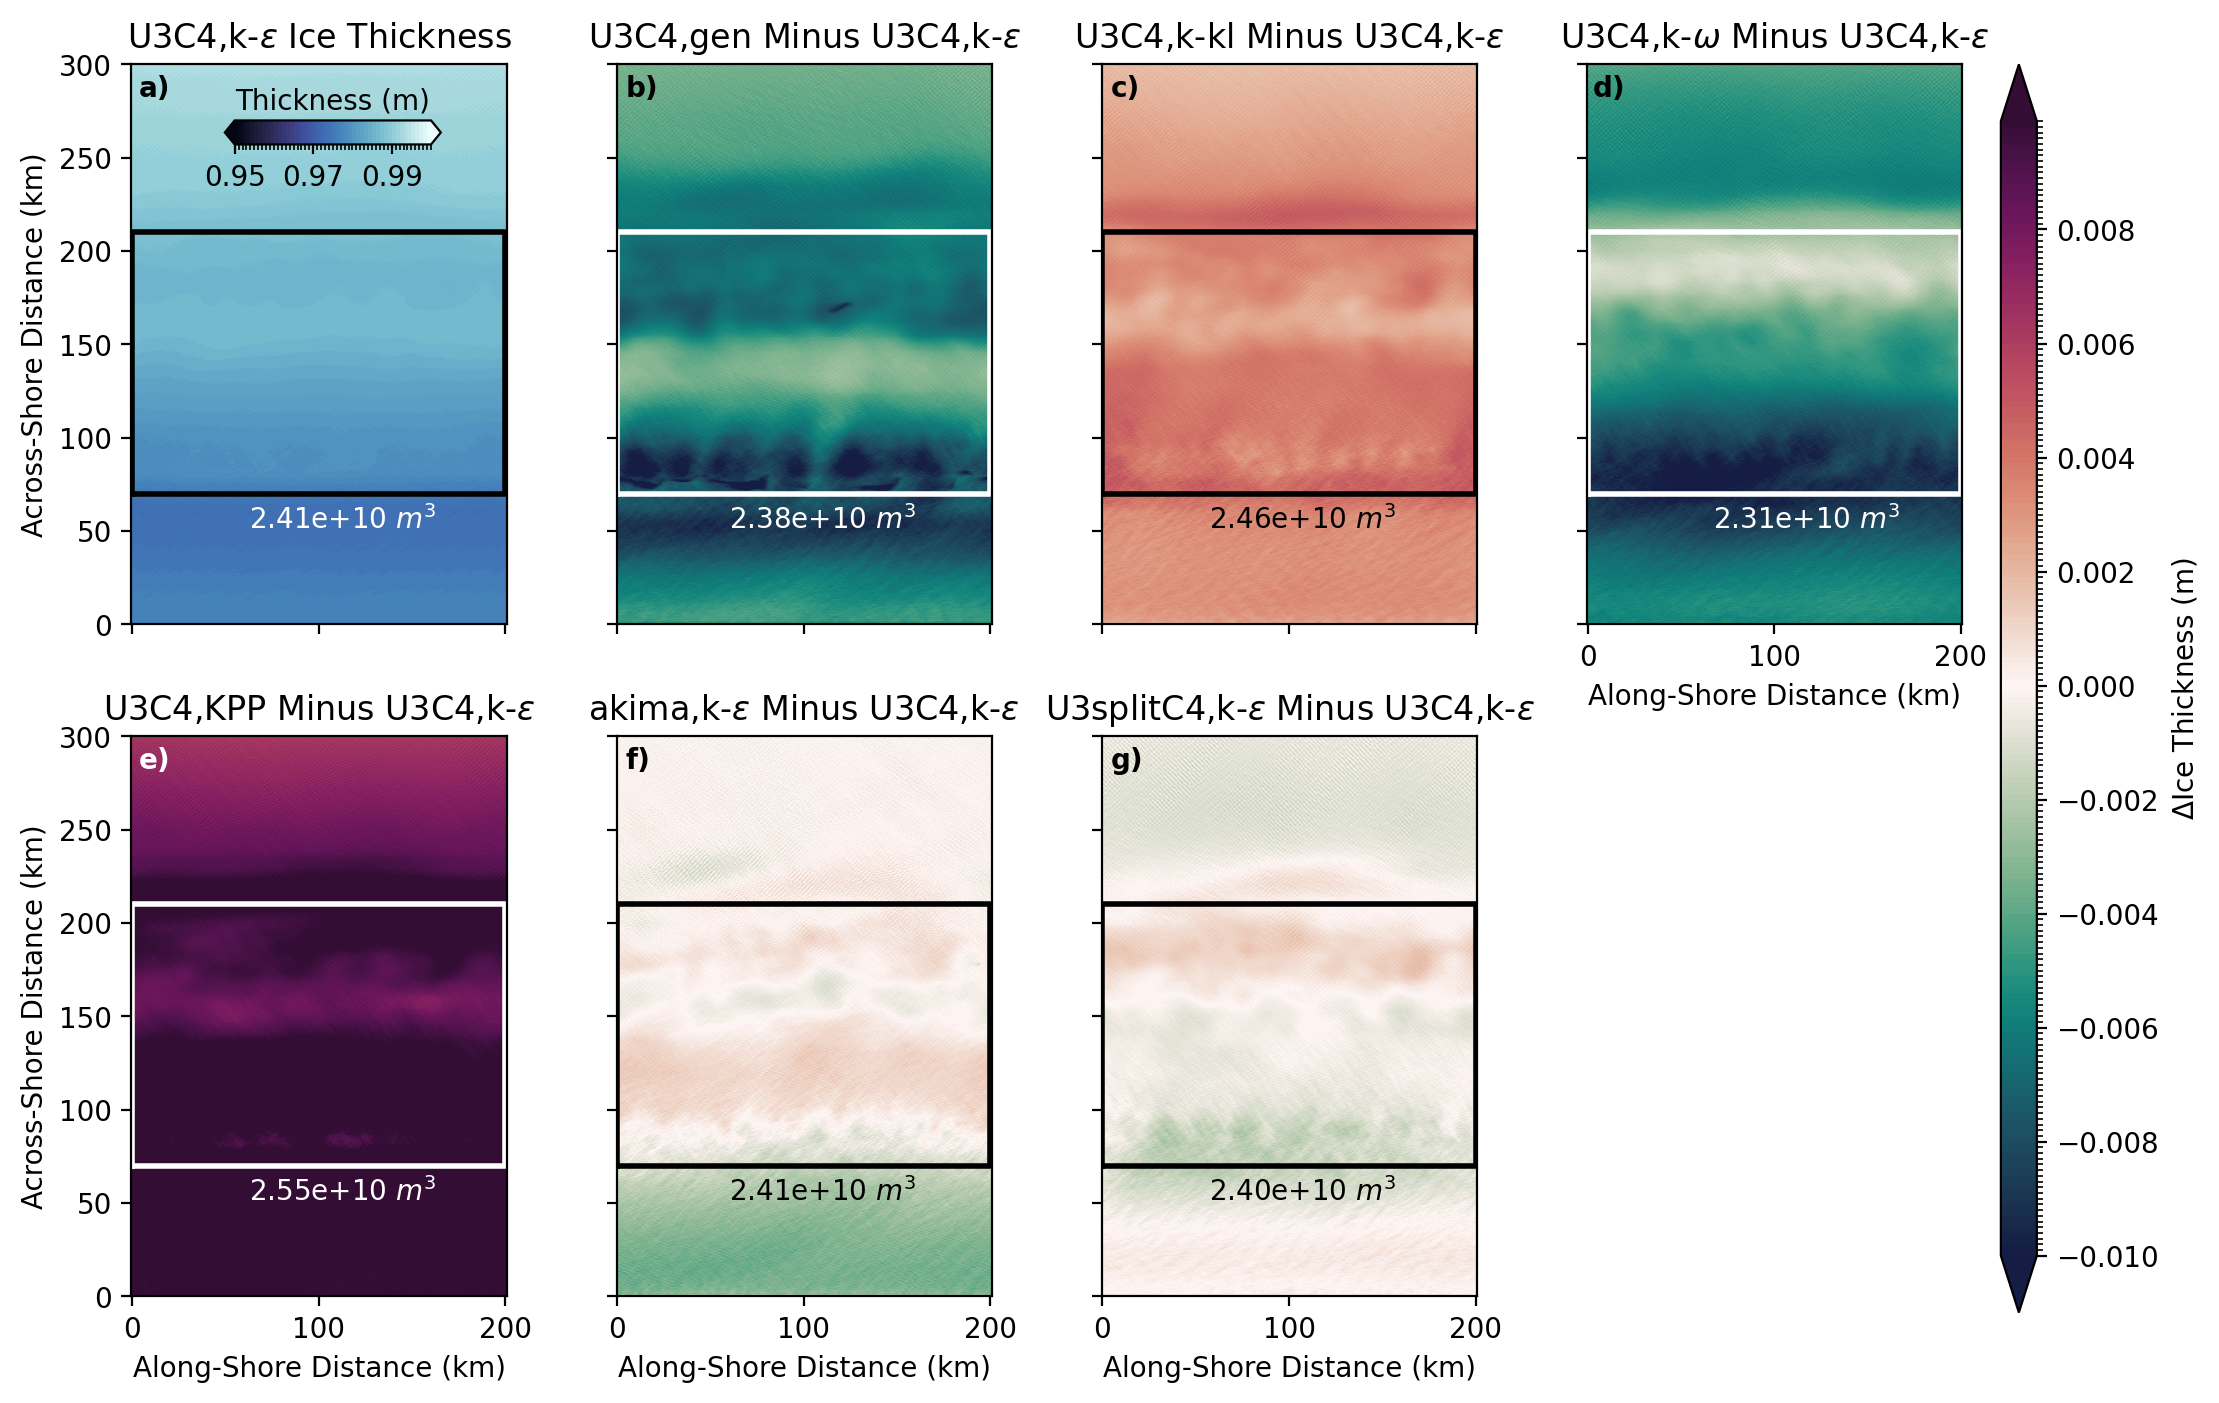

In [97]:
# Plot sea ice thickness snapshots on day 75 in all runs 
# Set the levels

# Make the figure 
fig, ax = plt.subplots(2, 4, figsize=(12,8), dpi=200)

# Plot the ice thickness
# U3C4, k-epsilon
p1 = ax[0,0].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_keps_75day,
                        cmap=cmap_ice_thick, norm=norm_ice_thick)
# Add a colorbar
cbar_ax1 = fig.add_axes([0.17,0.83,0.09,0.015])
cbar1 = plt.colorbar(p1, ax=ax[0,0], label='Thickness (m)', extend='both', ticks=[0.95,0.97,0.99],
                     format="%.2f", orientation='horizontal', cax=cbar_ax1)
cbar1.ax.xaxis.set_label_position('top')
# fig.colorbar(p1,ax=ax,extend='both', ticks=[30,31,32],
#              pad=0.03, orientation='horizontal', cax=cbar_ax1)

# U3C4, gen
p2 = ax[0,1].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_gen_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)
# U3C4, kkl
p3 = ax[0,2].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_kkl_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)
# U3C4, komega
p4 = ax[0,3].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_komega_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)
# U3C4, kpp
p5 = ax[1,0].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_kpp_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)
# akima, keps
p6 = ax[1,1].pcolormesh(x_rho/1000, y_rho/1000, aice_akima_keps_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)
# U3splitC4, keps
p7 = ax[1,2].pcolormesh(x_rho/1000, y_rho/1000, aice_u3splitc4_keps_min_u3c4_keps,
                        cmap=cmap_ice_thick_diff, norm=norm_ice_thick_diff2)

# Add the box
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
for r in range(2):
    for j in range(4):
        # plot the box
        # Plot Box 1
        if (r == 1 and j == 0):
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
            [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
            color='white', linestyle='-', linewidth=2)
        elif (r == 0 and j == 1):
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
            [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
            color='white', linestyle='-', linewidth=2)
        elif (r == 0 and j == 3):
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
            [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
            color='white', linestyle='-', linewidth=2)
        else:
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
                [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
                color='black', linestyle='-', linewidth=2)
        # ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        #         [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        #         color='lightgrey', linestyle='-', linewidth=2)
        
        
        # Set aspect
        ax[r,j].set_aspect(1.0)

        # Set axis limits
        ax[r,j].set_ylim(0,300)

# Delete unused axis
ax[1,3].remove()

# Add colorbar
cbar_ax2 = fig.add_axes([0.91,0.10,0.015,0.78])
cbar2 = plt.colorbar(p7, label='$\Delta$Ice Thickness (m)',
                     extend='both', pad=0.008, cax=cbar_ax2)

# Mute some axes
ax[0,0].set_xticklabels('')
ax[0,1].set_xticklabels('')
ax[0,1].set_yticklabels('')
ax[0,2].set_xticklabels('')
ax[0,2].set_yticklabels('')
#ax[0,3].set_xticklabels('')
ax[0,3].set_yticklabels('')
ax[1,1].set_yticklabels('')
ax[1,2].set_yticklabels('')

# Title the plots
ax[0,0].set_title('U3C4,k-$\epsilon$ Ice Thickness')
ax[0,1].set_title('U3C4,gen Minus U3C4,k-$\epsilon$')
ax[0,2].set_title('U3C4,k-kl Minus U3C4,k-$\epsilon$')
ax[0,3].set_title('U3C4,k-$\omega$ Minus U3C4,k-$\epsilon$')
ax[1,0].set_title('U3C4,KPP Minus U3C4,k-$\epsilon$')
ax[1,1].set_title('akima,k-$\epsilon$ Minus U3C4,k-$\epsilon$')
ax[1,2].set_title('U3splitC4,k-$\epsilon$ Minus U3C4,k-$\epsilon$')

# Label axes
ax[0,0].set_ylabel('Across-Shore Distance (km)')
ax[1,0].set_ylabel('Across-Shore Distance (km)')
ax[0,3].set_xlabel('Along-Shore Distance (km)')
ax[1,0].set_xlabel('Along-Shore Distance (km)')
ax[1,1].set_xlabel('Along-Shore Distance (km)')
ax[1,2].set_xlabel('Along-Shore Distance (km)')

# Add subplot labels 
fig.text(0.134, 0.860, 'a)', color='black', weight='bold')
fig.text(0.337, 0.860, 'b)', color='black', weight='bold')
fig.text(0.539, 0.860, 'c)', color='black', weight='bold')
fig.text(0.740, 0.860, 'd)', color='black', weight='bold')
fig.text(0.134, 0.440, 'e)', color='white', weight='bold')
fig.text(0.337, 0.440, 'f)', color='black', weight='bold')
fig.text(0.539, 0.440, 'g)', color='black', weight='bold')

# Optionally add the volume on the plot
fig.text(0.180, 0.59, f"{ice_vol_u3c4_keps_day75:.2e}"+' $m^{3}$', color='white')
fig.text(0.380, 0.59, f"{ice_vol_u3c4_gen_day75:.2e}"+' $m^{3}$', color='white')
fig.text(0.580, 0.59, f"{ice_vol_u3c4_kkl_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.790, 0.59, f"{ice_vol_u3c4_komega_day75:.2e}"+' $m^{3}$', color='white')
fig.text(0.180, 0.17, f"{ice_vol_u3c4_kpp_day75:.2e}"+' $m^{3}$', color='white')
fig.text(0.380, 0.17, f"{ice_vol_akima_keps_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.580, 0.17, f"{ice_vol_u3splitc4_keps_day75:.2e}"+' $m^{3}$', color='black')





Text(0.58, 0.17, '2.40e+10 $m^{3}$')

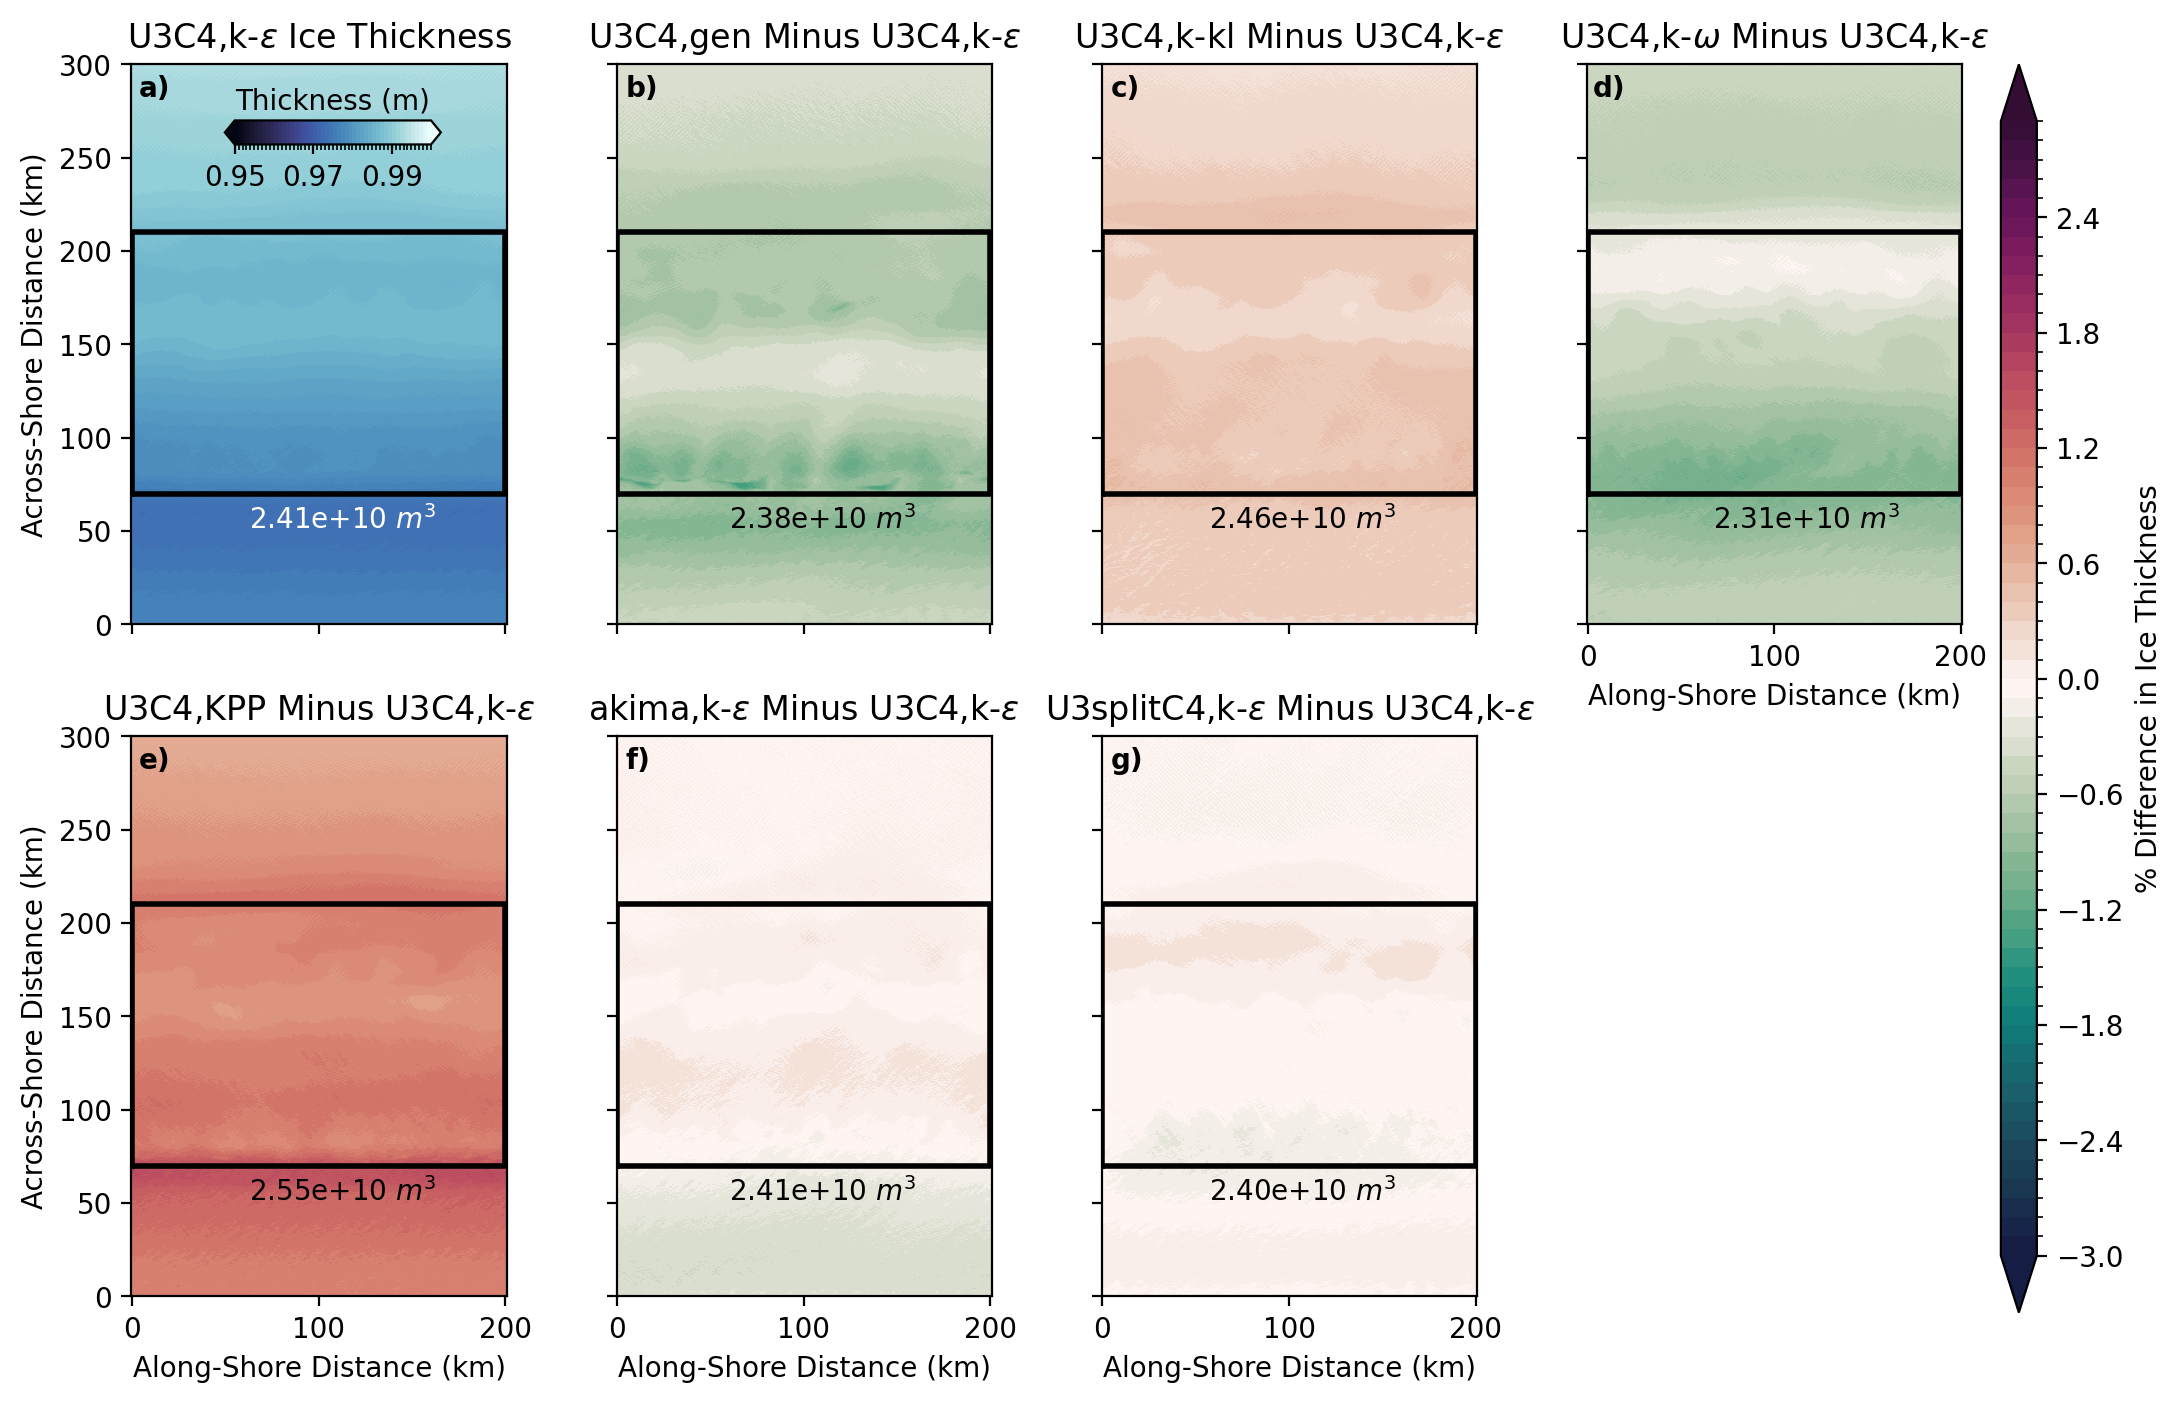

In [79]:
# Make another version of this plot that has 
# percent difference instead

# Make the figure 
fig, ax = plt.subplots(2, 4, figsize=(12,8), dpi=200)

# Plot the ice thickness
# U3C4, k-epsilon
p1 = ax[0,0].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_keps_75day,
                        cmap=cmap_ice_thick, norm=norm_ice_thick)
# Add a colorbar
cbar_ax1 = fig.add_axes([0.17,0.83,0.09,0.015])
cbar1 = plt.colorbar(p1, ax=ax[0,0], label='Thickness (m)', extend='both', ticks=[0.95,0.97,0.99],
                     format="%.2f", orientation='horizontal', cax=cbar_ax1)
cbar1.ax.xaxis.set_label_position('top')
# fig.colorbar(p1,ax=ax,extend='both', ticks=[30,31,32],
#              pad=0.03, orientation='horizontal', cax=cbar_ax1)

# U3C4, gen
p2 = ax[0,1].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_gen_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)
# U3C4, kkl
p3 = ax[0,2].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_kkl_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)
# U3C4, komega
p4 = ax[0,3].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_komega_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)
# U3C4, kpp
p5 = ax[1,0].pcolormesh(x_rho/1000, y_rho/1000, aice_u3c4_kpp_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)
# akima, keps
p6 = ax[1,1].pcolormesh(x_rho/1000, y_rho/1000, aice_akima_keps_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)
# U3splitC4, keps
p7 = ax[1,2].pcolormesh(x_rho/1000, y_rho/1000, aice_u3splitc4_keps_min_u3c4_keps_pct*100,
                        cmap=cmap_ice_thick_diff_pct, norm=norm_ice_thick_diff_pct)

# Add the box
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
for r in range(2):
    for j in range(4):
        # plot the box
        # Plot Box 1
        if (r == 1 and j == 0):
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
            [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
            color='black', linestyle='-', linewidth=2)
        elif (r == 0 and j == 3):
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
            [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
            color='black', linestyle='-', linewidth=2)
        else:
            ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
                [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
                color='black', linestyle='-', linewidth=2)
        # ax[r,j].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        #         [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        #         color='lightgrey', linestyle='-', linewidth=2)
        
        
        # Set aspect
        ax[r,j].set_aspect(1.0)

        # Set axis limits
        ax[r,j].set_ylim(0,300)

# Delete unused axis
ax[1,3].remove()

# Add colorbar
cbar_ax2 = fig.add_axes([0.91,0.10,0.015,0.78])
cbar2 = plt.colorbar(p7, label='% Difference in Ice Thickness',
                     extend='both', pad=0.008, cax=cbar_ax2)

# Mute some axes
ax[0,0].set_xticklabels('')
ax[0,1].set_xticklabels('')
ax[0,1].set_yticklabels('')
ax[0,2].set_xticklabels('')
ax[0,2].set_yticklabels('')
#ax[0,3].set_xticklabels('')
ax[0,3].set_yticklabels('')
ax[1,1].set_yticklabels('')
ax[1,2].set_yticklabels('')

# Title the plots
ax[0,0].set_title('U3C4,k-$\epsilon$ Ice Thickness')
ax[0,1].set_title('U3C4,gen Minus U3C4,k-$\epsilon$')
ax[0,2].set_title('U3C4,k-kl Minus U3C4,k-$\epsilon$')
ax[0,3].set_title('U3C4,k-$\omega$ Minus U3C4,k-$\epsilon$')
ax[1,0].set_title('U3C4,KPP Minus U3C4,k-$\epsilon$')
ax[1,1].set_title('akima,k-$\epsilon$ Minus U3C4,k-$\epsilon$')
ax[1,2].set_title('U3splitC4,k-$\epsilon$ Minus U3C4,k-$\epsilon$')

# Label axes
ax[0,0].set_ylabel('Across-Shore Distance (km)')
ax[1,0].set_ylabel('Across-Shore Distance (km)')
ax[0,3].set_xlabel('Along-Shore Distance (km)')
ax[1,0].set_xlabel('Along-Shore Distance (km)')
ax[1,1].set_xlabel('Along-Shore Distance (km)')
ax[1,2].set_xlabel('Along-Shore Distance (km)')

# Add subplot labels 
fig.text(0.134, 0.860, 'a)', color='black', weight='bold')
fig.text(0.337, 0.860, 'b)', color='black', weight='bold')
fig.text(0.539, 0.860, 'c)', color='black', weight='bold')
fig.text(0.740, 0.860, 'd)', color='black', weight='bold')
fig.text(0.134, 0.440, 'e)', color='black', weight='bold')
fig.text(0.337, 0.440, 'f)', color='black', weight='bold')
fig.text(0.539, 0.440, 'g)', color='black', weight='bold')

# Optionally add the volume on the plot
fig.text(0.180, 0.59, f"{ice_vol_u3c4_keps_day75:.2e}"+' $m^{3}$', color='white')
fig.text(0.380, 0.59, f"{ice_vol_u3c4_gen_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.580, 0.59, f"{ice_vol_u3c4_kkl_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.790, 0.59, f"{ice_vol_u3c4_komega_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.180, 0.17, f"{ice_vol_u3c4_kpp_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.380, 0.17, f"{ice_vol_akima_keps_day75:.2e}"+' $m^{3}$', color='black')
fig.text(0.580, 0.17, f"{ice_vol_u3splitc4_keps_day75:.2e}"+' $m^{3}$', color='black')


### Statistics!  
Print some bulk statistics

In [61]:
# Make a function to calculate the sum and ratio? or nah?

def calc_sum_mix_phys_num_ratio(phys_mix, num_mix):
    """
    This function takes a given timeseries of mixing, sums it up over time 
    for numerical and physical mixing, and takes the ratio.

    Inputs:
    - phys_mix: time series of physical mixing
    - num_mix: time series of numerical mixing

    Outputs: 
    - tot_phys_mix: sum of physical mixing over time
    - tot_num_mix: sum of numerical mixing over time
    - ratio_num_phys: ratio of total numerical mixing over total physical mixing
    """

    # Sum the physical mixing over time
    tot_phys_mix = phys_mix.sum(dim='ocean_time')

    # Sum the numerical mixing over time
    tot_num_mix = num_mix.sum(dim='ocean_time')

    # Take the ratio
    ratio_num_phys = tot_num_mix/tot_phys_mix

    # Return these values 
    return(tot_phys_mix, tot_num_mix, ratio_num_phys)

In [62]:
# Want the total amount of mixing for all schemes over 
# the 980 time steps, then wat the ratio of numerical to 
# physical for these schemes over time 

# NOTE: These are volume-integrated totals for now since things
# have not been divided by volume yet

# Get the total amount of mixing for each scheme
# --- Physical Mixing ---
# - Salt -
# U3C4, keps
salt_phys_tot_u3c4_keps, salt_num_tot_u3c4_keps, ratio_num_phys_salt_tot_u3c4_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_keps.mphys[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980])
print('U3C4, k-epsilon')
print('salt_phys_tot_u3c4_keps: ' , salt_phys_tot_u3c4_keps.values)
print('salt_num_tot_u3c4_keps: ', salt_num_tot_u3c4_keps.values)
print('ratio_num_phys_salt_tot_u3c4_keps: ', ratio_num_phys_salt_tot_u3c4_keps.values)
# U3C4, keps, no ice
salt_phys_tot_u3c4_keps_no_ice, salt_num_tot_u3c4_keps_no_ice, ratio_num_phys_salt_tot_u3c4_keps_no_ice = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_keps_no_ice.mphys[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv[:980])
print('U3C4, k-epsilon, no ice')
print('salt_phys_tot_u3c4_keps_no_ice: ' , salt_phys_tot_u3c4_keps_no_ice.values)
print('salt_num_tot_u3c4_keps_no_ice: ', salt_num_tot_u3c4_keps_no_ice.values)
print('ratio_num_phys_salt_tot_u3c4_keps_no_ice: ', ratio_num_phys_salt_tot_u3c4_keps_no_ice.values)
# U3C4, gen
salt_phys_tot_u3c4_gen, salt_num_tot_u3c4_gen, ratio_num_phys_salt_tot_u3c4_gen = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_gen.mphys[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980])
print('U3C4, gen')
print('salt_phys_tot_u3c4_gen: ' , salt_phys_tot_u3c4_gen.values)
print('salt_num_tot_u3c4_gen: ', salt_num_tot_u3c4_gen.values)
print('ratio_num_phys_salt_tot_u3c4_gen: ', ratio_num_phys_salt_tot_u3c4_gen.values)
# U3C4, kkl
salt_phys_tot_u3c4_kkl, salt_num_tot_u3c4_kkl, ratio_num_phys_salt_tot_u3c4_kkl = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_kkl.mphys[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980])
print('U3C4, kkl')
print('salt_phys_tot_u3c4_kkl: ' , salt_phys_tot_u3c4_kkl.values)
print('salt_num_tot_u3c4_kkl: ', salt_num_tot_u3c4_kkl.values)
print('ratio_num_phys_salt_tot_u3c4_kkl: ', ratio_num_phys_salt_tot_u3c4_kkl.values)
# U3C4, komega
salt_phys_tot_u3c4_komega, salt_num_tot_u3c4_komega, ratio_num_phys_salt_tot_u3c4_komega = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_komega.mphys[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980])
print('U3C4, komega')
print('salt_phys_tot_u3c4_komega: ' , salt_phys_tot_u3c4_komega.values)
print('salt_num_tot_u3c4_komega: ', salt_num_tot_u3c4_komega.values)
print('ratio_num_phys_salt_tot_u3c4_komega: ', ratio_num_phys_salt_tot_u3c4_komega.values)
# U3C4, kpp
salt_phys_tot_u3c4_kpp, salt_num_tot_u3c4_kpp, ratio_num_phys_salt_tot_u3c4_kpp = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_kpp.mphys[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980])
print('U3C4, kpp')
print('salt_phys_tot_u3c4_kpp: ' , salt_phys_tot_u3c4_kpp.values)
print('salt_num_tot_u3c4_kpp: ', salt_num_tot_u3c4_kpp.values)
print('ratio_num_phys_salt_tot_u3c4_kpp: ', ratio_num_phys_salt_tot_u3c4_kpp.values)
# akima, keps
salt_phys_tot_akima_keps, salt_num_tot_akima_keps, ratio_num_phys_salt_tot_akima_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_akima_keps.mphys[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980])
print('akima, k-epsilon')
print('salt_phys_tot_akima_keps: ' , salt_phys_tot_akima_keps.values)
print('salt_num_tot_akima_keps: ', salt_num_tot_akima_keps.values)
print('ratio_num_phys_salt_tot_akima_keps: ', ratio_num_phys_salt_tot_akima_keps.values)
# U3splitC4, keps
salt_phys_tot_u3splitc4_keps, salt_num_tot_u3splitc4_keps, ratio_num_phys_salt_tot_u3splitc4_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3splitc4_keps.mphys[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980])
print('U3splitC4, k-epsilon')
print('salt_phys_tot_u3splitc4_keps: ' , salt_phys_tot_u3splitc4_keps.values)
print('salt_num_tot_u3splitc4_keps: ', salt_num_tot_u3splitc4_keps.values)
print('ratio_num_phys_salt_tot_u3splitc4_keps: ', ratio_num_phys_salt_tot_u3splitc4_keps.values)




U3C4, k-epsilon
salt_phys_tot_u3c4_keps:  46131642.95523515
salt_num_tot_u3c4_keps:  5672674.838993391
ratio_num_phys_salt_tot_u3c4_keps:  0.12296711054704891
U3C4, k-epsilon, no ice
salt_phys_tot_u3c4_keps_no_ice:  121453061.51182625
salt_num_tot_u3c4_keps_no_ice:  53840453.85913241
ratio_num_phys_salt_tot_u3c4_keps_no_ice:  0.4433025663489743
U3C4, gen
salt_phys_tot_u3c4_gen:  11409265.586952288
salt_num_tot_u3c4_gen:  10406576.915680867
ratio_num_phys_salt_tot_u3c4_gen:  0.9121162827151554
U3C4, kkl
salt_phys_tot_u3c4_kkl:  38436104.29563731
salt_num_tot_u3c4_kkl:  6410979.011198526
ratio_num_phys_salt_tot_u3c4_kkl:  0.16679575437425911
U3C4, komega
salt_phys_tot_u3c4_komega:  45662418.859908484
salt_num_tot_u3c4_komega:  7868663.143575626
ratio_num_phys_salt_tot_u3c4_komega:  0.17232252123385206
U3C4, kpp
salt_phys_tot_u3c4_kpp:  20817795.295530014
salt_num_tot_u3c4_kpp:  9113332.186840136
ratio_num_phys_salt_tot_u3c4_kpp:  0.4377664424818773
akima, k-epsilon
salt_phys_tot_akima_ke

In [63]:
# - Temp - 
# U3C4, keps
temp_phys_tot_u3c4_keps, temp_num_tot_u3c4_keps, ratio_num_phys_temp_tot_u3c4_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_keps.mphyt[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980])
print('U3C4, k-epsilon')
print('temp_phys_tot_u3c4_keps: ' , temp_phys_tot_u3c4_keps.values)
print('temp_num_tot_u3c4_keps: ', temp_num_tot_u3c4_keps.values)
print('ratio_num_phys_temp_tot_u3c4_keps: ', ratio_num_phys_temp_tot_u3c4_keps.values)
# U3C4, keps, no ice
temp_phys_tot_u3c4_keps_no_ice, temp_num_tot_u3c4_keps_no_ice, ratio_num_phys_temp_tot_u3c4_keps_no_ice = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980])
print('U3C4, k-epsilon, no ice')
print('temp_phys_tot_u3c4_keps_no_ice: ' , temp_phys_tot_u3c4_keps_no_ice.values)
print('temp_num_tot_u3c4_keps_no_ice: ', temp_num_tot_u3c4_keps_no_ice.values)
print('ratio_num_phys_temp_tot_u3c4_keps_no_ice: ', ratio_num_phys_temp_tot_u3c4_keps_no_ice.values)
# U3C4, gen
temp_phys_tot_u3c4_gen, temp_num_tot_u3c4_gen, ratio_num_phys_temp_tot_u3c4_gen = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_gen.mphyt[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980])
print('U3C4, gen')
print('temp_phys_tot_u3c4_gen: ' , temp_phys_tot_u3c4_gen.values)
print('temp_num_tot_u3c4_gen: ', temp_num_tot_u3c4_gen.values)
print('ratio_num_phys_temp_tot_u3c4_gen: ', ratio_num_phys_temp_tot_u3c4_gen.values)
# U3C4, kkl
temp_phys_tot_u3c4_kkl, temp_num_tot_u3c4_kkl, ratio_num_phys_temp_tot_u3c4_kkl = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_kkl.mphyt[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980])
print('U3C4, kkl')
print('temp_phys_tot_u3c4_kkl: ' , temp_phys_tot_u3c4_kkl.values)
print('temp_num_tot_u3c4_kkl: ', temp_num_tot_u3c4_kkl.values)
print('ratio_num_phys_temp_tot_u3c4_kkl: ', ratio_num_phys_temp_tot_u3c4_kkl.values)
# U3C4, komega
temp_phys_tot_u3c4_komega, temp_num_tot_u3c4_komega, ratio_num_phys_temp_tot_u3c4_komega = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_komega.mphyt[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980])
print('U3C4, komega')
print('temp_phys_tot_u3c4_komega: ' , temp_phys_tot_u3c4_komega.values)
print('temp_num_tot_u3c4_komega: ', temp_num_tot_u3c4_komega.values)
print('ratio_num_phys_temp_tot_u3c4_komega: ', ratio_num_phys_temp_tot_u3c4_komega.values)
# U3C4, kpp
temp_phys_tot_u3c4_kpp, temp_num_tot_u3c4_kpp, ratio_num_phys_temp_tot_u3c4_kpp = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3c4_kpp.mphyt[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980])
print('U3C4, kpp')
print('temp_phys_tot_u3c4_kpp: ' , temp_phys_tot_u3c4_kpp.values)
print('temp_num_tot_u3c4_kpp: ', temp_num_tot_u3c4_kpp.values)
print('ratio_num_phys_temp_tot_u3c4_kpp: ', ratio_num_phys_temp_tot_u3c4_kpp.values)
# akima, keps
temp_phys_tot_akima_keps, temp_num_tot_akima_keps, ratio_num_phys_temp_tot_akima_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_akima_keps.mphyt[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980])
print('akima, k-epsilon')
print('temp_phys_tot_akima_keps: ' , temp_phys_tot_akima_keps.values)
print('temp_num_tot_akima_keps: ', temp_num_tot_akima_keps.values)
print('ratio_num_phys_temp_tot_akima_keps: ', ratio_num_phys_temp_tot_akima_keps.values)
# U3splitC4, keps
temp_phys_tot_u3splitc4_keps, temp_num_tot_u3splitc4_keps, ratio_num_phys_temp_tot_u3splitc4_keps = calc_sum_mix_phys_num_ratio(roms_phy_num_mix_u3splitc4_keps.mphyt[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980])
print('U3splitC4, k-epsilon')
print('temp_phys_tot_u3splitc4_keps: ' , temp_phys_tot_u3splitc4_keps.values)
print('temp_num_tot_u3splitc4_keps: ', temp_num_tot_u3splitc4_keps.values)
print('ratio_num_phys_temp_tot_u3splitc4_keps: ', ratio_num_phys_temp_tot_u3splitc4_keps.values)

U3C4, k-epsilon
temp_phys_tot_u3c4_keps:  84379048.15111476
temp_num_tot_u3c4_keps:  10268792.775719937
ratio_num_phys_temp_tot_u3c4_keps:  0.12169837182009349
U3C4, k-epsilon, no ice
temp_phys_tot_u3c4_keps_no_ice:  1865585265.1626797
temp_num_tot_u3c4_keps_no_ice:  1010477557.6431884
ratio_num_phys_temp_tot_u3c4_keps_no_ice:  0.5416410477250818
U3C4, gen
temp_phys_tot_u3c4_gen:  90482566.9564436
temp_num_tot_u3c4_gen:  18679182.2066408
ratio_num_phys_temp_tot_u3c4_gen:  0.20643956990778747
U3C4, kkl
temp_phys_tot_u3c4_kkl:  79262783.15748717
temp_num_tot_u3c4_kkl:  11355437.818893768
ratio_num_phys_temp_tot_u3c4_kkl:  0.14326317303710692
U3C4, komega
temp_phys_tot_u3c4_komega:  123808332.00376606
temp_num_tot_u3c4_komega:  60630847.57336398
ratio_num_phys_temp_tot_u3c4_komega:  0.4897154059996518
U3C4, kpp
temp_phys_tot_u3c4_kpp:  108395868.18496192
temp_num_tot_u3c4_kpp:  22431619.905427963
ratio_num_phys_temp_tot_u3c4_kpp:  0.20694165083074603
akima, k-epsilon
temp_phys_tot_akima_k

In [ ]:
print(np.where(roms_phy_num_mix_akima_keps.mnum_salt_dv[:980] < 0))